# MIE 446 — Aerospace Structures
## Lecture 01: From Airfoil Geometry to Trustworthy Wing Loads

**Multi-session lecture | Interactive student notebook | No prior aerospace course required**

This lecture uses one repeated learning pattern:

> **Theory → Figure → Predict → Test with code → Explain the limitation**

The code is intentionally simple to operate. Your work is to choose inputs, predict the result, interpret the plots, and decide whether the result is trustworthy.

### Learning outcomes

By the end of this lecture sequence, you should be able to:

1. use Newton's second law to distinguish force balance from steady-flight assumptions;
2. identify chord, camber, thickness, leading edge, trailing edge, relative wind, and angle of attack;
3. explain how surface pressure and viscous shear combine into lift, drag, and pitching moment;
4. decode and compare NACA 4-digit airfoils;
5. use dynamic pressure and nondimensional coefficients to calculate forces and moment;
6. test a simple lift-versus-angle model and identify where it fails;
7. trace a wing load from the air to the aircraft and audit a polished AI-generated claim;
8. distinguish force balance, pitching-moment trim and stability, and explain how CG location changes required tail load;
9. identify tail controls, antiservo tabs, truss members and stressed-skin stiffeners using the seven FAA figures.

### Teaching route across multiple sessions

All original explanations, demonstrations and exercises remain available. The FAA figure discussions extend the lecture; there is no fixed duration limit. Pause between modules for derivations, predictions, code experiments and discussion.

| Module | Focus | Student action |
|---:|---|---|
| 1 | Start | Run the environment check; save a copy |
| 2 | Trustworthy engineering | Predict before calculating |
| 3 | Four forces and Newton's law | Resolve forces in general flight-path axes |
| 4 | Airfoil language and surface loads | Read two figures; audit pressure and shear claims |
| 5 | NACA 4-digit studio | Predict and compare two geometries |
| 6 | Coefficients and force scaling | Test speed, density, area, and coefficient changes |
| 7 | Angle of attack and stall | Test a deliberately limited model |
| 8 | Structural bridge and AI audit | Trace the load; assess evidence |
| 9 | Exit ticket | Make one claim with a check and limitation |

**Added discussions:** use Sections 2D–2I for aircraft axes, CG, moment balance and tail controls; use the expanded 7A and Sections 7D–7E for stringers, trusses and shell construction. Work through these in addition to the original flight-path and airfoil activities.

**Colab:** choose **File → Save a copy in Drive** before editing. Complete each prediction before running the experiment that follows it.

In [ ]:
#@title 0. Start here — environment check { display-mode: "form" }
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon, Rectangle, Arc
from IPython.display import Markdown, display

COLORS = {
    "navy": "#17365D",
    "blue": "#2F75B5",
    "cyan": "#5B9BD5",
    "orange": "#ED7D31",
    "green": "#70AD47",
    "red": "#C00000",
    "gray": "#666666",
    "light": "#EAF2F8",
}

plt.rcParams.update({
    "figure.figsize": (9.2, 5.2),
    "figure.dpi": 115,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "font.size": 11,
    "axes.titleweight": "bold",
})

print("MIE 446 Lecture 01 environment check: PASS")
print(f"  Python: {sys.version.split()[0]}")
print(f"  NumPy: {np.__version__}")
print("  Matplotlib: ready")
print("No installation or internet download is required.")

---
## 1. What makes an engineering answer trustworthy?

An engineering result is not trustworthy merely because the algebra is correct or the plot is smooth. It must connect a physical question to evidence through visible assumptions.

### The course reasoning cycle

1. **Frame** — define the system, axes, knowns, unknowns, loads, and constraints.
2. **Predict** — state the expected sign, trend, scale, or critical location.
3. **Model** — select equations and idealizations; name the assumptions.
4. **Solve** — calculate with a path another person can inspect.
5. **Audit** — check units, equilibrium, limiting cases, sensitivity, and an independent estimate.
6. **Explain and decide** — connect evidence to a claim; state confidence and limitations.

Throughout MIE 446, communicate with five labels:

> **Claim — Evidence — Check — Confidence — Limitation**

AI may help generate code, algebra, or possible explanations. It cannot take responsibility for defining the physical system, verifying assumptions, or deciding whether the evidence is sufficient.

In [ ]:
#@title 1A. Figure — the evidence chain { display-mode: "form" }
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 3)
ax.axis("off")

labels = ["Physical\nquestion", "Assumptions\n+ model", "Calculation\n/ code", "Independent\nchecks", "Engineering\ndecision"]
colors = [COLORS["navy"], COLORS["blue"], COLORS["cyan"], COLORS["green"], COLORS["orange"]]
xs = np.linspace(0.8, 9.2, len(labels))

for i, (x, label, color) in enumerate(zip(xs, labels, colors)):
    box = Rectangle((x - 0.75, 1.05), 1.5, 0.9, facecolor=color, edgecolor="white", linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, 1.5, label, ha="center", va="center", color="white", weight="bold", fontsize=10)
    if i < len(labels) - 1:
        ax.add_patch(FancyArrowPatch((x + 0.78, 1.5), (xs[i + 1] - 0.78, 1.5),
                                     arrowstyle="-|>", mutation_scale=14, lw=1.8,
                                     color=COLORS["gray"]))

ax.text(5, 2.55, "A number becomes evidence only when this chain is visible", ha="center",
        fontsize=14, weight="bold", color=COLORS["navy"])
ax.text(5, 0.42, "A polished answer can fail at any link — especially assumptions and checks.",
        ha="center", color=COLORS["red"], weight="bold")
plt.show()

### Model, result, and reality are different objects

| Object | Example | What can go wrong? |
|---|---|---|
| Physical aircraft | A flexible wing in gusty, viscous flow | Unknown conditions, variability, damage |
| Model | Rigid wing, steady uniform flow | Missing flexibility, stall, gusts, 3-D effects |
| Computed result | Lift = 4.2 kN | Input error, unit error, coding error |
| Decision | The design is adequate | Wrong failure mode or insufficient margin |

The purpose of a model is not to reproduce everything. It is to retain the physics needed for the question and to expose what has been omitted.

In [ ]:
#@title 1B. Check understanding ▶ — trustworthy engineering evidence { display-mode: "form" }
#@markdown **Scenario:** An AI tool reports, “The lift is 4.2 kN,” but gives no assumptions, governing equation, unit check, or independent check.
#@markdown Based on the reasoning cycle taught above, what is the most defensible assessment? Explain your choice, then press **▶** to check.
EVIDENCE_VERDICT = "Choose"  #@param ["Choose", "Accept because the number is precise", "Accept if the code ran without errors", "Treat as preliminary until assumptions, evidence, and checks are supplied", "Reject every answer produced with AI"]
EVIDENCE_REASON = ""  #@param {type:"string"}

correct_answer = "Treat as preliminary until assumptions, evidence, and checks are supplied"
if EVIDENCE_VERDICT == "Choose" or not EVIDENCE_REASON.strip():
    display(Markdown("⚠️ Choose an assessment and explain it before checking."))
elif EVIDENCE_VERDICT == correct_answer:
    display(Markdown(
        "✅ **Correct.** A computed value is not yet a trustworthy engineering conclusion. "
        "The system, assumptions, model, units, and independent checks must be visible before the evidence can support a decision.  \n"
        f"**Your explanation:** {EVIDENCE_REASON}"
    ))
else:
    display(Markdown(
        "❌ **Reconsider.** Precision or error-free execution does not validate the physical model, "
        "and responsible AI use does not require rejecting every AI-assisted result. Apply the taught "
        "Frame–Predict–Model–Solve–Audit cycle.  \n"
        f"**Your explanation:** {EVIDENCE_REASON}"
    ))


---
## 2. Four forces, a free-body diagram, and Newton's law

### Theory

For a chosen system, Newton's second law is

$$
\sum \mathbf{F}_{ext}=m\mathbf{a}_{CG}.
$$

For a simplified aircraft in the vertical plane:

- **Weight** $W=mg$ acts toward Earth through the center of gravity.
- **Lift** $L$ is the aerodynamic force component perpendicular to the relative wind.
- **Drag** $D$ is the aerodynamic force component opposite to the aircraft velocity relative to the air (in the relative-wind direction).
- **Thrust** $T$ is generated by the propulsion system; its direction need not always align perfectly with velocity.

The two-panel figure below separates **flight-path angle $\gamma$** (side view, path versus horizontal) from **bank angle $\phi$** (front view, wings versus horizontal, equivalently lift versus vertical). Panel A shows a climb; panel B shows a coordinated level turn. These are two distinct cases, not one combined maneuver. Change the sliders to explore each angle.

### General flight-path equations — use these before comparing lift with weight

Let the tangential axis $t$ point along the velocity and the normal axis $n$ point perpendicular to the flight path. Let $\gamma$ be the flight-path angle above the horizontal. If thrust is aligned with the flight path, then

$$
\sum F_t=T-D-W\sin\gamma=m\dot V,
$$

$$
\sum F_n=L-W\cos\gamma=mV\dot\gamma=\frac{mV^2}{R}.
$$

These equations give the important special cases:

- **steady straight climb or descent:** $\dot V=0$ and $\dot\gamma=0$, so $L=W\cos\gamma$ and $T-D=W\sin\gamma$;
- **steady straight level flight:** $\gamma=0$, so $L=W$ and $T=D$;
- **coordinated level turn with bank angle $\phi$:** $L\cos\phi=W$, so $L=W/\cos\phi>W$ when $\phi\ne0$.

Therefore, lift and weight are not generally equal. Their relationship follows from the acceleration, flight-path angle, bank angle, and thrust direction. If thrust is not aligned with the flight path, its tangential and normal components must also be included.

In [ ]:
#@title 2A. Explore flight-path angle gamma and bank angle phi { display-mode: "form" }
#@markdown **Explore:** How do flight-path angle $\gamma$ and bank angle $\phi$ change the force components?
#@markdown Set both angles, then press **▶** to redraw the two views.
GAMMA_DEG = 20.0 #@param {type:"slider", min:0, max:35, step:1}
PHI_DEG = 30.0 #@param {type:"slider", min:0, max:60, step:1}

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch, Arc, Circle

def draw_flight_angles(gamma_deg, phi_deg):
    if not (0 <= gamma_deg <= 35 and 0 <= phi_deg <= 60):
        raise ValueError('Use gamma in [0, 35] and phi in [0, 60] degrees.')
    navy, blue, red, green, orange = '#17324d', '#1776b6', '#c73338', '#25804b', '#d57820'
    fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
    fig.subplots_adjust(top=.83, bottom=.23, wspace=.12)
    def arrow(ax, end, color, start=(0,0), dashed=False):
        ax.add_patch(FancyArrowPatch(start, end, arrowstyle='-|>', mutation_scale=21,
                     lw=2.7, color=color, linestyle='--' if dashed else '-', zorder=5))
    def label(ax, x, y, text, color=navy, **kwargs):
        ax.text(x,y,text,color=color,fontsize=12,ha='center',va='center',
                bbox=dict(facecolor='white',edgecolor='none',alpha=.88,pad=2),zorder=8,**kwargs)
    for ax in axes:
        ax.set(xlim=(-3.6,3.6),ylim=(-2.8,3.3),aspect='equal')
        ax.axis('off')
    ax=axes[0]
    g=np.deg2rad(gamma_deg)
    t=np.array([np.cos(g),np.sin(g)])
    n=np.array([-np.sin(g),np.cos(g)])
    rot=np.column_stack((t,n))
    # Side profile: rounded nose to the right, vertical fin at the tail.
    fuselage=np.array([[-2.1,0],[-1.8,.14],[-1.75,.7],[-1.45,.68],[-1.1,.17],
                       [.9,.18],[1.55,.1],[1.95,0],[1.6,-.12],[-1.7,-.12]])
    ax.add_patch(Polygon(fuselage@rot.T,facecolor='#dce9f3',edgecolor=navy,lw=1.7,zorder=2))
    wing=np.array([[-.6,.03],[.45,.05],[-.05,-.42],[-.7,-.42]])
    ax.add_patch(Polygon(wing@rot.T,facecolor='#a5c9df',edgecolor=navy,lw=1.4,zorder=3))
    ax.plot([0,3.35],[0,0],':',color='#7f8b97',lw=1.5)
    ax.plot(*np.column_stack((-3.1*t,3.2*t)),ls='--',color='#7f8b97',lw=1.3)
    arrow(ax,2.9*t,green); arrow(ax,-2.8*t,orange)
    arrow(ax,2.7*n,blue); arrow(ax,(0,-2.35),red)
    label(ax,*(2.95*t+np.array([0,.3])),r'$T,\;V$ (along path)',green)
    label(ax,*(-2.85*t+np.array([0,-.32])),r'$D$ (opposes motion)',orange)
    label(ax,*(2.75*n+np.array([-.3,.15])),r'$L$ (normal to path)',blue)
    label(ax,.55,-2.4,r'$W=mg$',red)
    label(ax,2.85,-.28,'Horizontal')
    ax.add_patch(Arc((0,0),3.2,3.2,theta1=0,theta2=gamma_deg,color='#8045a0',lw=2.8,zorder=7))
    label(ax,2*np.cos(g/2),2*np.sin(g/2),rf'$\gamma={gamma_deg:.0f}^\circ$','#8045a0')
    # Weight projections on the flight-path axes reconstruct vertical weight.
    wt=-2.35*np.sin(g)*t; wn=-2.35*np.cos(g)*n
    arrow(ax,wt,red,dashed=True); arrow(ax,wn,red,dashed=True)
    ax.plot([wt[0],0,wn[0]],[wt[1],-2.35,wn[1]],':',color=red,lw=1.2)
    label(ax,-1.7,-1.85,r'$-W\sin\gamma$ along $t$',red)
    label(ax,1.5,-1.85,r'$-W\cos\gamma$ along $n$',red)
    ax.plot(0,0,'o',color=navy,zorder=10); label(ax,-.35,.35,'CG')
    ax.set_title('A  |  Straight climb — side view',loc='left',color=navy,weight='bold',pad=20)
    ax=axes[1]; p=np.deg2rad(phi_deg)
    lift=2.65; vertical=lift*np.cos(p)
    end=np.array([lift*np.sin(p),vertical])
    wing_axis=np.array([np.cos(p),-np.sin(p)])
    ax.plot([-3.2,3.2],[0,0],':',color='#7f8b97',lw=1.5)
    ax.plot([0,0],[0,3.05],':',color='#7f8b97',lw=1.5)
    ax.plot(*np.column_stack((-2.5*wing_axis,2.5*wing_axis)),color=navy,lw=8,solid_capstyle='round',zorder=3)
    ax.add_patch(Circle((0,0),.19,facecolor='#dce9f3',edgecolor=navy,lw=2,zorder=6))
    arrow(ax,end,blue); arrow(ax,(0,vertical),green,dashed=True)
    arrow(ax,(end[0],0),orange,dashed=True); arrow(ax,(0,-vertical),red)
    ax.plot([0,end[0],end[0]],[vertical,vertical,0],':',color=blue,lw=1.5)
    ax.add_patch(Arc((0,0),2,2,theta1=90-phi_deg,theta2=90,color='#8045a0',lw=2.8,zorder=7))
    label(ax,1.4*np.sin(p/2),1.4*np.cos(p/2),rf'$\phi={phi_deg:.0f}^\circ$','#8045a0')
    ax.add_patch(Arc((0,0),2.5,2.5,theta1=-phi_deg,theta2=0,color='#8045a0',lw=2,zorder=7))
    label(ax,1.7*np.cos(p/2),-1.7*np.sin(p/2),r'$\phi$','#8045a0')
    label(ax,end[0]+.3,end[1]+.32,r'$L$',blue)
    label(ax,-1.05,vertical,r'$L\cos\phi=W$',green)
    label(ax,max(.9,end[0]/2),.35,r'$L\sin\phi$',orange)
    label(ax,.55,-vertical-.1,r'$W=mg$',red)
    label(ax,2.5,-2.4,'Toward turn center →',orange)
    label(ax,-.65,3,'Vertical')
    ax.set_title('B  |  Coordinated level turn — front view',loc='left',color=navy,weight='bold',pad=20)
    fig.suptitle('Flight-path angle and bank angle describe different rotations',fontsize=19,weight='bold',color=navy,y=.96)
    fig.text(.27,.16,r'$T-D-W\sin\gamma=m\dot V\qquad L-W\cos\gamma=mV\dot\gamma$',ha='center',fontsize=14,color=navy)
    fig.text(.27,.115,r'Steady straight climb: $L=W\cos\gamma$',ha='center',fontsize=12,color=navy)
    fig.text(.76,.16,r'$L\cos\phi=W\qquad L\sin\phi=mV^2/R_{turn}$',ha='center',fontsize=14,color=navy)
    fig.text(.76,.115,r'Level turn: $L=W/\cos\phi$',ha='center',fontsize=12,color=navy)
    fig.text(.5,.04,'A: wings level, thrust aligned with path.  B: constant altitude, coordinated turn; thrust/drag out of view.\nAircraft are schematic; force arrows are instructional. Change the two sliders and rerun.',ha='center',fontsize=10,color='#526273')
    return fig

fig = draw_flight_angles(GAMMA_DEG, PHI_DEG)
plt.show()


In [ ]:
#@title 2B. Check answer ▶ — force balance { display-mode: "form" }
#@markdown **Question 1:** In a steady straight climb with $\gamma=10^\circ$ and thrust aligned with the path, compare $L$ with $W$.
#@markdown **Question 2:** If $L=10.0$ kN and $W=8.829$ kN at the same $\gamma$, what is the sign of normal acceleration?
#@markdown Choose both answers, state the normal-force equation, then press **▶** to check.
STEADY_CLIMB_RELATION = "Choose"  #@param ["Choose", "L < W", "L = W", "L > W"]
SCENARIO_PREDICTION = "Choose"  #@param ["Choose", "Positive normal acceleration", "Zero normal acceleration", "Negative normal acceleration"]
PREDICTION_REASON = ""  #@param {type:"string"}

if "Choose" in (STEADY_CLIMB_RELATION, SCENARIO_PREDICTION) or not PREDICTION_REASON.strip():
    display(Markdown("⚠️ Complete both predictions and state which normal-force equation you used."))
else:
    correct_relation = STEADY_CLIMB_RELATION == "L < W"
    correct_tendency = SCENARIO_PREDICTION == "Positive normal acceleration"
    score = int(correct_relation) + int(correct_tendency)
    rn_example = 10000.0 - 8829.0*np.cos(np.deg2rad(10.0))
    icon = "✅" if score == 2 else "❌"
    display(Markdown(
        f"{icon} **Score: {score}/2.** For steady straight climb, "
        r"$L-W\cos\gamma=0$, so $L=W\cos\gamma<W$. "
        rf"For the stated forces, $L-W\cos\gamma={rn_example:.0f}$ N, so normal acceleration is **positive**.  \n"
        f"**Your reason:** {PREDICTION_REASON}"
    ))


In [ ]:
#@title 2C. Test — change the forces and compute the acceleration tendency { display-mode: "form" }
#@markdown **Explore:** Change the forces and angles. What tangential and normal acceleration should Newton's law predict?
#@markdown Set the inputs, then press **▶** to calculate and plot the result.
MASS_KG = 900.0  #@param {type:"number"}
LIFT_N = 10000.0  #@param {type:"number"}
WEIGHT_N = 8829.0  #@param {type:"number"}
THRUST_N = 2200.0  #@param {type:"number"}
DRAG_N = 1800.0  #@param {type:"number"}
FLIGHT_PATH_ANGLE_DEG = 10.0  #@param {type:"number"}
BANK_ANGLE_DEG = 30.0  #@param {type:"number"}

if MASS_KG <= 0:
    raise ValueError("Mass must be positive.")
if abs(BANK_ANGLE_DEG) >= 89.9:
    raise ValueError("Use a bank angle with magnitude below 89.9 degrees.")

gamma = np.deg2rad(FLIGHT_PATH_ANGLE_DEG)
phi = np.deg2rad(BANK_ANGLE_DEG)
rt = THRUST_N - DRAG_N - WEIGHT_N*np.sin(gamma)
rn = LIFT_N - WEIGHT_N*np.cos(gamma)
at_cg = rt / MASS_KG
an_cg = rn / MASS_KG
steady_climb_lift = WEIGHT_N*np.cos(gamma)
level_turn_lift = WEIGHT_N/np.cos(phi)

tol = 1e-9
normal = "positive normal acceleration" if an_cg > tol else "negative normal acceleration" if an_cg < -tol else "zero normal acceleration"
tangential = "speeding up" if at_cg > tol else "slowing down" if at_cg < -tol else "constant instantaneous speed"

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
component_labels = ["T", "-D", r"-$W\sin\gamma$", "L", r"-$W\cos\gamma$"]
component_values = [THRUST_N, -DRAG_N, -WEIGHT_N*np.sin(gamma), LIFT_N, -WEIGHT_N*np.cos(gamma)]
axes[0].bar(component_labels, component_values,
            color=[COLORS["green"], COLORS["orange"], COLORS["red"], COLORS["blue"], COLORS["red"]])
axes[0].axhline(0, color="black", lw=1)
axes[0].set_ylabel("Signed component (N)")
axes[0].set_title("Flight-path force components")
axes[0].tick_params(axis="x", rotation=12)

axes[1].bar([r"$\dot V=a_t$", r"$a_n=V\dot\gamma$"], [at_cg, an_cg], color=[COLORS["green"], COLORS["blue"]])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_ylabel(r"Acceleration (m/s$^2$)")
axes[1].set_title("Newton's-law result")

fig.suptitle(f"At γ={FLIGHT_PATH_ANGLE_DEG:.1f}°: ΣFt={rt:.1f} N, ΣFn={rn:.1f} N",
             color=COLORS["navy"], weight="bold")
fig.tight_layout()
plt.show()

display(Markdown(
    fr'''**General-flight result:** {tangential}; **{normal}**.  
$a_t={at_cg:.3f}\;\mathrm{{m/s^2}}$, $a_n={an_cg:.3f}\;\mathrm{{m/s^2}}$.  
For a steady straight path at this $\gamma$, required lift is $W\cos\gamma={steady_climb_lift:.1f}$ N.  
For a level coordinated bank at $\phi={BANK_ANGLE_DEG:.1f}^\circ$, required lift is $W/\cos\phi={level_turn_lift:.1f}$ N.'''
))
display(Markdown(
    r"**Audit:** compare $L$ with $W\cos\gamma$ in the normal equation, not automatically with $W$. "
    "The plot gives an instantaneous rigid-body tendency; it does not establish the future flight path."
))

### What this test established — and what it did not

The flight-path residuals determine the instantaneous tangential and normal acceleration of the chosen rigid-body model. They do **not** prove that the aircraft will continue accelerating in the same way: as velocity and orientation change, lift, drag, and thrust can also change.

**Independent checks:**

- units: N/kg = m/s²;
- sign: the normal residual is positive when $L>W\cos\gamma$;
- limiting case: for $\gamma=0$, setting $L=W$ and $T=D$ must return both residuals as zero;
- turn check: at nonzero bank angle, a level coordinated turn requires $L=W/\cos\phi$;
- scale: an acceleration larger than several $g$ would demand scrutiny of inputs and model.

### 2D. Aircraft rotations and the moments that produce them — Figure 3-2

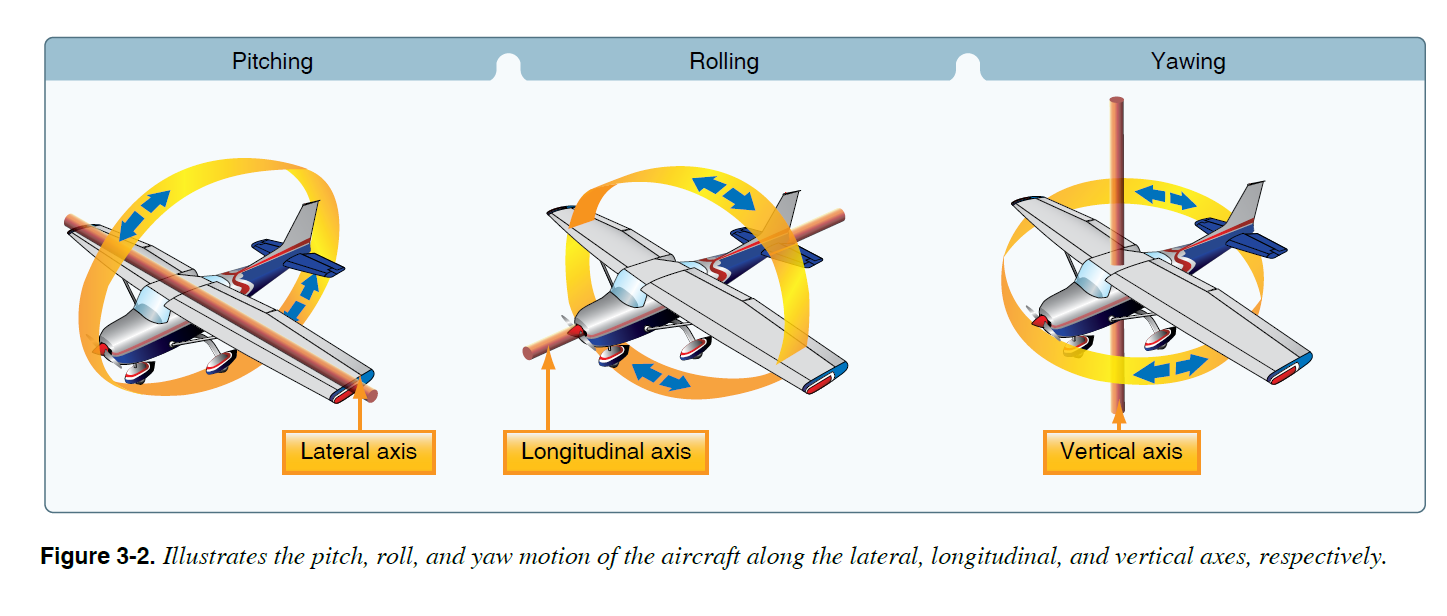

*FAA Figure 3-2, printed page 3-3. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=3). The explanation and calculations below are course additions.*

Read the arrows as **rotations about axes**, not translations along them. Imagine holding the airplane at its center of gravity (CG). It can pitch its nose up/down, roll one wing down, or yaw its nose left/right. A force changes translational motion; a net moment changes angular momentum. Balanced forces alone therefore do not guarantee balanced rotation.

Use right-handed **body axes** through the CG: $x_b$ forward, $y_b$ toward the right wing, and $z_b$ downward. These axes turn with the airplane; they are not the flight-path axes used above.

| Motion | Axis | Moment and usual positive sense | Main conventional control |
|---|---|---|---|
| Roll | Longitudinal, $x_b$ | $\mathcal L$: right wing down | Ailerons |
| Pitch | Lateral, $y_b$ | $\mathcal M$: nose up | Elevator or stabilator |
| Yaw | Vertical body axis, $z_b$ | $\mathcal N$: nose right | Rudder |

We write roll moment as $\mathcal L$ to distinguish it from lift $L$. In a bank or pitch attitude the body $z_b$ axis is not Earth-vertical. Controls can have coupled effects: for example, aileron deflection can also change drag and produce yaw.

For a force $\mathbf F_i$ applied at position $\mathbf r_i$ measured from the CG,

$$\mathbf M_{i,CG}=\mathbf r_i\times\mathbf F_i,\qquad
\sum\mathbf M_{CG}=\sum_i\mathbf r_i\times\mathbf F_i+\sum_j\mathbf M_{\mathrm{couple},j}.$$

The perpendicular lever arm matters: $|M|=F d_\perp$. Units are N m. A force through the CG has zero lever arm, but an applied couple can remain. For a rigid aircraft, expressed in body axes,

$$\boxed{\sum\mathbf M_{CG}=\mathbf I_{CG}\dot{\boldsymbol\omega}
+\boldsymbol\omega\times(\mathbf I_{CG}\boldsymbol\omega).}$$

$\mathbf I_{CG}$ is the mass-inertia tensor (kg m$^2$), and $\boldsymbol\omega$ is angular velocity (rad/s). For isolated pitch about a principal axis, this reduces to $\sum\mathcal M_{CG}=I_{yy}\ddot\theta$. We use $\theta$ for pitch attitude; it is not automatically equal to angle of attack $\alpha$ or flight-path angle $\gamma$. In planar flight without wind complications, $\alpha=\theta-\gamma$.

**Predict:** equal upward and downward forces separated horizontally give zero net force. Do they also give zero moment? **Check:** no; they form a couple. The aircraft can have zero translational acceleration and nonzero pitch acceleration.


### 2E. Where is the center of gravity? — Figure 3-3

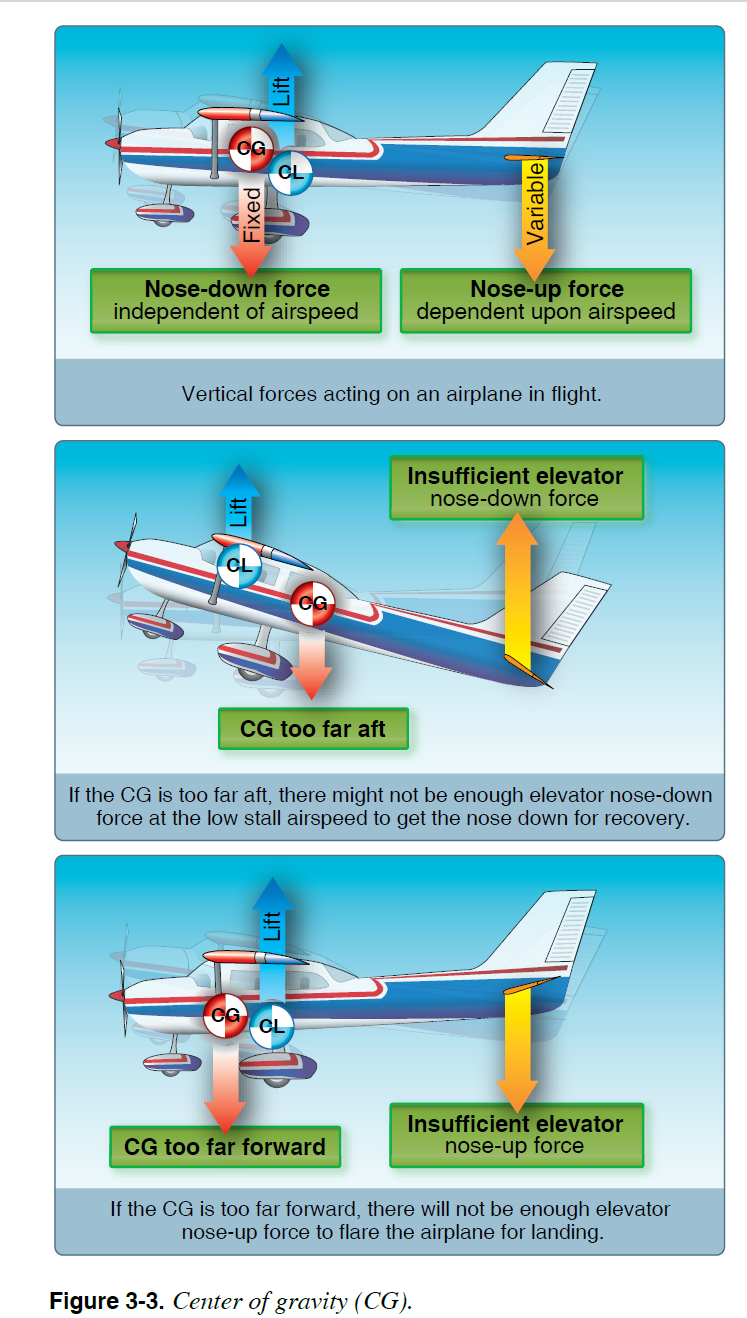

*FAA Figure 3-3, printed page 3-4. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=4). The explanation and calculations below are course additions.*

The **center of mass** is the mass-weighted average position. In the approximately uniform gravitational field used here, it is also the center of gravity. For components at positions $\mathbf r_i$,

$$\boxed{\mathbf r_{CG}=\frac{\sum_i m_i\mathbf r_i}{\sum_i m_i}.}$$

For longitudinal loading calculations, measure every station $s_i$ from the same chosen datum, increasing aft:

$$s_{CG}=\frac{\sum_i m_i s_i}{\sum_i m_i}.$$

The datum is a reference plane, not necessarily the nose. Empty aircraft, engine, occupants, baggage and fuel all contribute. High-wing versus low-wing geometry alone does not locate the CG. The vertical and lateral positions matter too, although this introductory trim calculation focuses on the longitudinal position.

**Example:** an 800 kg aircraft component group at station 2.0 m plus 200 kg of payload at 3.0 m has $s_{CG}=2.20$ m. Moving that same payload to 4.0 m moves the CG to 2.40 m without changing the total weight. Burning fuel can move the CG forward or aft depending on tank location and fuel-management sequence.

| Aircraft configuration | What determines CG location and balance? |
|---|---|
| Conventional airplane with an aft tail | Mass distribution sets CG; wing, tail and propulsion moments determine trim. The illustrated condition uses downward tail force, but tail load is not always downward. |
| Transport aircraft or sailplane | Passenger/cargo or pilot/ballast placement and fuel distribution affect CG. Location is often reported relative to mean aerodynamic chord; there is no universal allowable percentage. |
| Canard aircraft | A lifting foreplane ahead of the CG can supply a nose-up moment; its load must be balanced with the main wing and other moments. |
| Flying wing or tailless aircraft | Wing loading, sweep, airfoil pitching moment and control-surface deflections provide trim without a separate aft horizontal tail. The same force and moment laws apply. |

The actual permitted CG envelope comes from the aircraft's approved loading information; a schematic cannot supply it. A common reporting convention is

$$\%MAC=100\frac{s_{CG}-s_{LEMAC}}{\bar c},$$

where $s_{LEMAC}$ locates the leading edge of the mean aerodynamic chord and $\bar c$ is its length. **25% MAC is not a universal CG target or limit.**

**Read the FAA figure critically.** Its label “CL” means *center of lift*, not the coefficient $C_L$. Its “nose-up/down force” labels describe the **turning effect** of forces, not a new kind of force. Weight acts through the CG and creates **zero moment about the CG**. A moment of weight would appear if moments were instead taken about another point. “Fixed” means weight does not directly scale with airspeed for a fixed loading condition; it does not mean weight stays fixed as fuel burns.


### 2F. Balance both force and moment: derive the tail load

For a transparent **steady, straight, level** example, assume vertical wing and tail resultants, horizontal thrust and drag, and no angular acceleration. Let $L_w$ be the wing lift and $L_t$ the **signed** tail force, positive upward. Total aerodynamic lift in the earlier equation $L=W$ is $L=L_w+L_t$ in this simplified two-surface model.

Define signed aft distances from the CG: $d_w=s_w-s_{CG}$ and $d_t=s_t-s_{CG}$. A positive $d$ means behind the CG. These scalar aft distances are distinct from the forward-positive body coordinate $x_b$. Take pitching moment positive nose-up. An upward force behind the CG makes the nose rotate down; therefore its moment is $-dL$.

Represent the wing aerodynamic loading by a lift at a specified reference point plus its moment $M_{w,\mathrm{ref}}$. Let $M_0$ include this reference moment and all other retained pitching couples or offset-thrust/drag contributions. Do not also place the same lift at its center of pressure and count the reference moment again.

$$\boxed{L_w+L_t-W=0,\qquad T-D=0,}$$
$$\boxed{\sum\mathcal M_{CG}=M_0-d_wL_w-d_tL_t=0.}$$

Substitute $L_w=W-L_t$ into the moment equation:

$$M_0-d_wW+(d_w-d_t)L_t=0,$$
$$\boxed{L_t=\frac{M_0-d_wW}{d_t-d_w},\qquad L_w=W-L_t.}$$

This solves two equilibrium equations together. All force locations and couples must correspond to the same physical model. If thrust has a vertical component, include it in vertical balance; if its line misses the CG, include its moment too.

**Worked example (illustrative, not an aircraft loading recommendation):** $W=10{,}000$ N, $d_w=0.30$ m, $d_t=4.00$ m and $M_0=-500$ N m give

$$L_t=-945.95\ \mathrm N,\qquad L_w=10{,}945.95\ \mathrm N.$$

The negative tail value means **downforce**. Its nose-up moment balances the nose-down wing-force moment and the negative reference moment. The wing must carry more than the aircraft weight because it must also counter the downward tail force. Check the moment residual:

$$-500-(0.30)(10{,}945.95)-(4.00)(-945.95)\approx0\ \mathrm{N\,m}.$$

**Trim is not stability.** Trim means the net moment is zero at one operating point. Static pitch stability asks whether a small increase in angle of attack creates a restoring nose-down moment; in the usual convention this requires $\partial C_m/\partial\alpha<0$ near trim with the specified controls fixed. For a conventional statically stable design, the CG lies forward of the relevant neutral point, which is a property of the **whole aircraft**, not simply the wing's center of lift. Dynamic stability additionally depends on damping and motion over time.

Moving the CG aft generally reduces static margin in that conventional model; moving it too far forward can demand more nose-up control than is available. At low airspeed, the available aerodynamic tail force can be limited because $L_t=\tfrac12\rho V_t^2 S_t C_{L_t}$. Here $V_t$ is local tail airspeed, $S_t$ is tail area and $C_{L_t}$ depends on tail incidence, downwash and control deflection. The figure illustrates control-authority concerns; the trim equations alone do not predict stall recovery or certify a CG limit.

**Before running the next cell:** move the CG aft by 0.20 m while leaving wing and tail stations fixed. Predict whether the required tail downforce increases or decreases. This experiment tests equilibrium only; it contains no stability derivatives.


In [ ]:
#@title 2G. Test CG movement: solve force and pitching-moment balance
CG_SHIFT_AFT_M = 0.0 #@param {type:"slider", min:-0.2, max:0.4, step:0.05}
# Independent illustrative variables: do not overwrite the earlier flight-path model.
trim_weight = 10000.0
trim_m0 = -500.0
trim_dw = 0.30 - CG_SHIFT_AFT_M
trim_dt = 4.00 - CG_SHIFT_AFT_M
trim_tail = (trim_m0 - trim_dw * trim_weight) / (trim_dt - trim_dw)
trim_wing = trim_weight - trim_tail
trim_force_residual = trim_wing + trim_tail - trim_weight
trim_moment_residual = trim_m0 - trim_dw*trim_wing - trim_dt*trim_tail
assert abs(trim_force_residual) < 1e-8
assert abs(trim_moment_residual) < 1e-8
print(f"CG shift aft: {CG_SHIFT_AFT_M:+.2f} m")
print(f"Distances aft of CG: wing {trim_dw:+.2f} m; tail {trim_dt:+.2f} m")
print(f"Wing lift: {trim_wing:.2f} N")
print(f"Signed tail force: {trim_tail:+.2f} N (negative = downforce)")
print(f"Vertical force residual: {trim_force_residual:.3e} N")
print(f"Nose-up moment contributions [N m]: M0={trim_m0:.2f}, wing={-trim_dw*trim_wing:.2f}, tail={-trim_dt*trim_tail:.2f}")
print(f"Pitch-moment residual: {trim_moment_residual:.3e} N m")
print("These are required equilibrium loads, not a calculation of stability or available control authority.")
print("Explain: how can total lift equal weight while wing lift exceeds weight?")


### 2H. Tail components turn control motion into aircraft moment — Figure 3-10

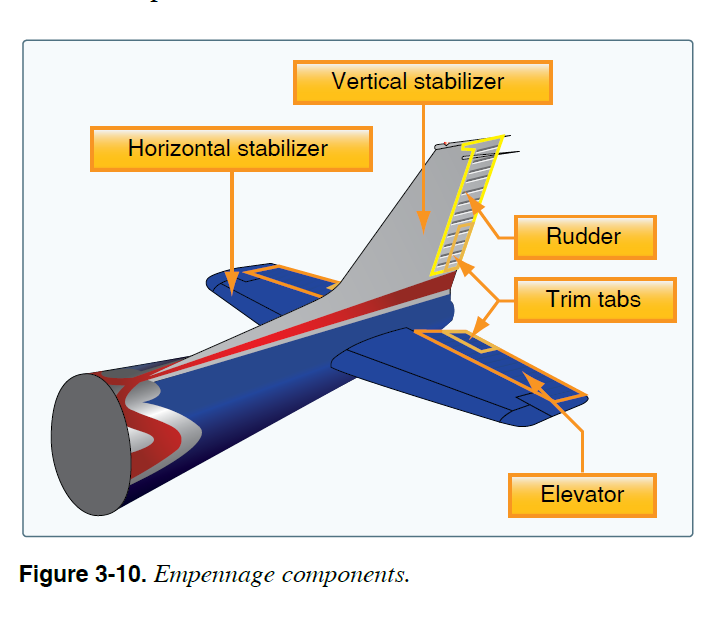

*FAA Figure 3-10, printed page 3-6. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=6). The explanation and calculations below are course additions.*

**Empennage** means the tail assembly. Distinguish the main supporting surfaces from the movable controls:

| Component | What moves and what it does | Structural consequence |
|---|---|---|
| Horizontal stabilizer | In this conventional arrangement it supports the elevator and contributes to longitudinal stability and trim | Carries aerodynamic load to the rear fuselage; some other designs have adjustable stabilizer incidence |
| Elevator | Hinged trailing-edge surface; deflection changes tail aerodynamic force and pitching moment | Hinges, actuator/linkage and tail structure carry control loads |
| Vertical stabilizer (fin) | Fixed vertical surface; contributes to directional stability | Its lateral load produces bending and shear at the fin root |
| Rudder | Hinged surface behind the fin; changes side force and yawing moment | Loads pass through rudder hinges and fin into the fuselage |
| Trim tabs | Small trailing-edge surfaces set to reduce sustained control effort | Their aerodynamic force creates a moment about the main control's hinge |

The elevator does not directly push on the nose. It changes airflow and force at the tail, and the **tail lever arm** converts that force into a pitching moment about the CG. For fixed geometry, $\Delta\mathcal M_{CG}=-d_t\Delta L_t$. In the usual aft-tail response, moving the elevator trailing edge up makes the tail load more downward (or less upward), producing a nose-up increment.

This introduces **two different moments**: the tail force produces an aircraft pitching moment about the **CG**, whereas the aerodynamic load on a movable surface produces a **hinge moment** that the control system and pilot must oppose. A trim tab mainly helps with the second. It does not move the mass center to balance the airplane.

**Trace the load:** air pressure on the tail/control → skin, ribs and spars → hinges or tail attachments → rear fuselage → the rest of the aircraft. A tail force much smaller than wing lift can still create a substantial aircraft moment because its lever arm is long.


### 2I. Stabilator and antiservo tab — Figure 3-11

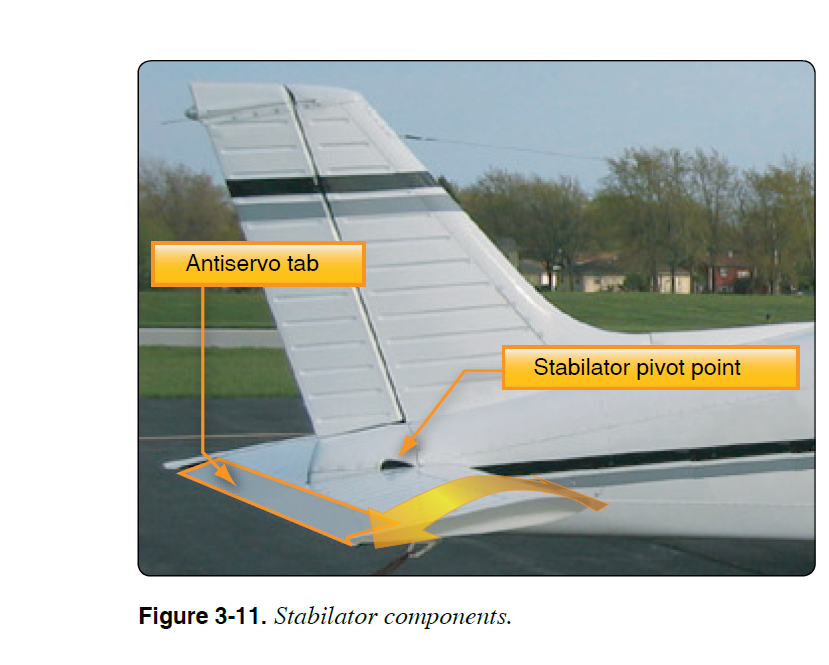

*FAA Figure 3-11, printed page 3-7. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=7). The explanation and calculations below are course additions.*

A **stabilator** is an all-moving horizontal tail: the main surface rotates about its pivot to provide pitch control. It differs from the separate fixed stabilizer and hinged elevator in Figure 3-10. The photograph identifies the pivot and the narrow trailing-edge antiservo tab; a single photograph does not itself show the motion sequence.

On the illustrated type, when the stabilator trailing edge moves up, the linkage deflects the antiservo tab **up relative to the stabilator** as well. A downward stabilator movement produces corresponding downward tab deflection. That additional tab deflection creates an aerodynamic hinge-moment contribution that **resists** the commanded stabilator movement and increases control feel. This helps prevent an overly sensitive all-moving tail.

| Device | Main purpose | Key distinction |
|---|---|---|
| Trim tab | Relieve sustained pilot control force at the chosen condition | Sets the control's hinge-moment balance; it is not a CG adjustment |
| Servo tab | Aerodynamically assist movement of the main control | Its force helps drive the main surface; conventional arrangements deflect it oppositely |
| Antiservo tab | Increase resistance/feel and reduce excessive sensitivity | Same-sense relative deflection on the stabilator arrangement shown |

An antiservo tab can also incorporate a trim adjustment; these functions are compatible. Do not identify every small tab as an antiservo tab simply by appearance. The linkage and relative motion determine its role.

The tab force acts with a lever arm about the stabilator pivot. Schematically, its hinge-moment contribution scales as $H_{\mathrm{tab}}\sim F_{\mathrm{tab}}\ell_h$, with units N m. This is not the same lever arm as the CG-to-tail distance in the aircraft trim equation. **Check understanding:** explain why adding resistance at the stabilator pivot can improve control feel even though the pilot is still able to command a pitching moment about the CG.


---
## 3. Airfoil geometry, relative wind, and surface loads

### Geometry theory

An **airfoil** is a two-dimensional section of a wing. It is not the whole finite wing.

- **Leading edge (LE):** forward-most point.
- **Trailing edge (TE):** aft point where upper and lower surfaces meet.
- **Chord line:** straight line from LE to TE; chord length is $c$.
- **Mean camber line:** locus midway between upper and lower surfaces.
- **Thickness:** distance between upper and lower surfaces, measured perpendicular to the camber line in the formal construction.
- **Relative wind:** airflow velocity seen by the airfoil, opposite the airfoil's motion through still air.
- **Angle of attack $\alpha$:** angle from relative wind to the chord line, with a stated sign convention.

Camber and angle of attack are not the same. Camber is built into the shape; angle of attack describes the shape's orientation relative to the flow.

In [ ]:
#@title 3A. Figure — airfoil anatomy and angle of attack { display-mode: "form" }
# A pedagogical cambered airfoil used only to label the geometry
x = np.linspace(0, 1, 400)
camber = 0.035 * np.sin(np.pi * x)
thickness = 0.12 * (0.2969*np.sqrt(np.maximum(x, 1e-12)) - 0.1260*x
                    - 0.3516*x**2 + 0.2843*x**3 - 0.1036*x**4) / 0.2
yu = camber + thickness/2
yl = camber - thickness/2

alpha_deg = 12.0
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(x, yl, yu, color="#D9EAF7", alpha=0.9)
ax.plot(x, yu, color=COLORS["navy"], lw=2, label="Upper surface")
ax.plot(x, yl, color=COLORS["navy"], lw=2, label="Lower surface")
ax.plot(x, camber, "--", color=COLORS["orange"], lw=2, label="Mean camber line")
ax.plot([0, 1], [0, 0], ":", color=COLORS["red"], lw=2, label="Chord line")

# Relative wind and angle-of-attack annotation
x0, y0 = -0.34, -0.14
length = 0.43
theta = np.deg2rad(-alpha_deg)
ax.add_patch(FancyArrowPatch((x0, y0), (x0+length*np.cos(theta), y0+length*np.sin(theta)),
                             arrowstyle="-|>", mutation_scale=16, lw=2.5, color=COLORS["green"]))
ax.add_patch(FancyArrowPatch((x0, y0), (x0+0.38, y0), arrowstyle="-|>",
                             mutation_scale=14, lw=1.8, color=COLORS["red"]))
ax.add_patch(Arc((x0, y0), 0.42, 0.42, angle=0, theta1=-alpha_deg, theta2=0,
                 color=COLORS["red"], lw=2))
ax.text(x0+0.02, y0-0.075, "Relative wind", color=COLORS["green"], weight="bold")
ax.text(x0+0.17, y0+0.025, "chord direction", color=COLORS["red"], fontsize=9, weight="bold")
ax.text(x0+0.12, y0-0.055, r"$\alpha$", color=COLORS["red"], weight="bold", fontsize=13)

ax.scatter([0, 1], [0, 0], color=COLORS["red"], zorder=5)
ax.annotate("Leading edge", (0, 0), xytext=(0.05, 0.16), arrowprops=dict(arrowstyle="->"))
ax.annotate("Trailing edge", (1, 0), xytext=(0.77, 0.16), arrowprops=dict(arrowstyle="->"))

i_t = np.argmax(yu - yl)
ax.annotate("Maximum thickness", (x[i_t], yu[i_t]), xytext=(0.37, 0.20),
            arrowprops=dict(arrowstyle="->", color=COLORS["blue"]), color=COLORS["blue"], weight="bold")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.45, 1.08)
ax.set_ylim(-0.28, 0.26)
ax.set_xlabel("x/c")
ax.set_ylabel("y/c")
ax.set_title("Airfoil vocabulary: shape and orientation are separate ideas")
ax.legend(loc="lower right", ncol=2, fontsize=9)
plt.show()

In [ ]:
#@title 3B. Check answer ▶ — separate shape from operating condition { display-mode: "form" }
#@markdown **Question:** Which quantity can change during flight without changing the manufactured airfoil shape?
#@markdown Choose an answer, explain why, then press **▶** to check.
GEOMETRY_ANSWER = "Choose"  #@param ["Choose", "Camber", "Thickness", "Angle of attack", "Chord"]
GEOMETRY_REASON = ""  #@param {type:"string"}

if GEOMETRY_ANSWER == "Choose" or not GEOMETRY_REASON.strip():
    display(Markdown("⚠️ Choose an answer and enter your explanation before checking."))
elif GEOMETRY_ANSWER == "Angle of attack":
    display(Markdown("✅ **Angle of attack.** It changes with the orientation of the chord relative to the flow."))
else:
    display(Markdown("❌ Recheck the definitions: camber, thickness, and chord are geometric properties of the manufactured section."))

if GEOMETRY_REASON.strip():
    display(Markdown(f"**Your explanation:** {GEOMETRY_REASON}"))

### Surface-load theory: where lift, drag, and moment come from

At every point on the airfoil surface, the fluid applies a **traction** with two parts:
$$
\mathbf{t}=\underbrace{-p\mathbf{n}}_{\text{pressure: normal to the surface}}
+\underbrace{\boldsymbol{\tau}_w}_{\text{viscous shear: tangent to the surface}},
$$
where $\mathbf{n}$ is the outward unit normal. Integrating this traction gives the aerodynamic force per unit span for a two-dimensional airfoil; integrating its moment gives the pitching moment:
$$
\mathbf{F}'_{aero}=\oint_C\left(-p\mathbf{n}+\boldsymbol{\tau}_w\right)ds,
\qquad
\mathbf{M}'_O=\oint_C\mathbf{r}\times\left(-p\mathbf{n}+\boldsymbol{\tau}_w\right)ds.
$$

Let $\mathbf{e}_D$ point downstream, parallel to the freestream, and let $\mathbf{e}_L$ be perpendicular to the freestream. Lift and drag are projections of the **same resultant traction**:
$$
\begin{aligned}
L' &= \mathbf{F}'_{aero}\!\cdot\!\mathbf{e}_L
    = \underbrace{\oint_C(-p\mathbf{n})\!\cdot\!\mathbf{e}_L\,ds}_{L'_p}
    + \underbrace{\oint_C\boldsymbol{\tau}_w\!\cdot\!\mathbf{e}_L\,ds}_{L'_{\tau}},\\[2mm]
D' &= \mathbf{F}'_{aero}\!\cdot\!\mathbf{e}_D
    = \underbrace{\oint_C(-p\mathbf{n})\!\cdot\!\mathbf{e}_D\,ds}_{D'_p}
    + \underbrace{\oint_C\boldsymbol{\tau}_w\!\cdot\!\mathbf{e}_D\,ds}_{D'_{\tau}}.
\end{aligned}
$$
Thus **pressure and shear can each contribute to both lift and drag**. In many attached, low-angle airfoil flows, pressure dominates lift and wall shear is an important part of drag, but that is a result—not a definition.

For an airfoil described by upper and lower surfaces $y_u(x)$ and $y_\ell(x)$, with $x$ aligned with the freestream, the pressure contributions reduce to
$$
\boxed{L'_p=\int_0^c\left[p_\ell(x)-p_u(x)\right]dx}
$$
and
$$
\boxed{D'_p=\int_0^c\left[p_u(x)\frac{dy_u}{dx}-p_\ell(x)\frac{dy_\ell}{dx}\right]dx}.
$$
The viscous contribution must still be projected along the lift and drag directions:
$$
D'_{\tau}=\int_{C_u}\boldsymbol{\tau}_w\!\cdot\!\mathbf{e}_D\,ds
+\int_{C_\ell}\boldsymbol{\tau}_w\!\cdot\!\mathbf{e}_D\,ds,
\qquad
L'_{\tau}=\oint_C\boldsymbol{\tau}_w\!\cdot\!\mathbf{e}_L\,ds.
$$

The boxed expressions use a two-dimensional airfoil, steady surface pressures, and axes aligned with the freestream. For a finite three-dimensional wing, use the vector surface integral over the entire wetted surface. The pressure field itself comes from conservation laws and boundary conditions as the flow accelerates and turns around the body. Avoid the false “equal transit time” story: upper- and lower-surface fluid particles are not required to reunite at the trailing edge.


In [ ]:
#@title 3C. Figure — pressure normal to the surface, shear tangent to it { display-mode: "form" }
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(x, yl, yu, color="#EAF2F8", zorder=1)
ax.plot(x, yu, color=COLORS["navy"], lw=2)
ax.plot(x, yl, color=COLORS["navy"], lw=2)

# Schematic pressure arrows: normal to the local surface, deliberately not quantitative
sample_idx = np.linspace(30, 350, 10, dtype=int)
dyu = np.gradient(yu, x)
dyl = np.gradient(yl, x)
for j in sample_idx:
    # outward normal to upper surface
    n_up = np.array([-dyu[j], 1.0]); n_up /= np.linalg.norm(n_up)
    mag_up = 0.045 + 0.07*np.exp(-((x[j]-0.25)/0.25)**2)
    start = np.array([x[j], yu[j]]) + n_up*mag_up
    end = np.array([x[j], yu[j]])
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=10,
                                 lw=1.4, color=COLORS["blue"]))
    # outward normal to lower surface
    n_lo = np.array([dyl[j], -1.0]); n_lo /= np.linalg.norm(n_lo)
    mag_lo = 0.035 + 0.025*np.exp(-((x[j]-0.35)/0.35)**2)
    start = np.array([x[j], yl[j]]) + n_lo*mag_lo
    end = np.array([x[j], yl[j]])
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=10,
                                 lw=1.4, color=COLORS["orange"]))

# Viscous shear vectors at several surface points. Each vector is tangent to
# the local surface and points downstream in this schematic.
shear_idx = [60, 125, 200, 275, 340]
for j in shear_idx:
    t_up = np.array([1.0, dyu[j]]); t_up /= np.linalg.norm(t_up)
    t_lo = np.array([1.0, dyl[j]]); t_lo /= np.linalg.norm(t_lo)
    start_up = np.array([x[j], yu[j]]) + np.array([-dyu[j], 1.0])*0.004
    start_lo = np.array([x[j], yl[j]]) - np.array([-dyl[j], 1.0])*0.004
    ax.add_patch(FancyArrowPatch(start_up, start_up + 0.075*t_up,
                                 arrowstyle="-|>", mutation_scale=10,
                                 lw=2.0, color=COLORS["green"], zorder=5))
    ax.add_patch(FancyArrowPatch(start_lo, start_lo + 0.075*t_lo,
                                 arrowstyle="-|>", mutation_scale=10,
                                 lw=2.0, color=COLORS["green"], zorder=5))

ax.annotate("viscous shear vectors\n(tangent to the surface)",
            xy=(x[275]+0.045, yu[275]+0.01), xytext=(0.68, 0.20),
            arrowprops=dict(arrowstyle="->", color=COLORS["green"]),
            color=COLORS["green"], fontsize=9, weight="bold")

ax.annotate("pressure traction (normal)", xy=(0.22, yu[90]+0.09), xytext=(0.02, 0.23),
            arrowprops=dict(arrowstyle="->", color=COLORS["blue"]), color=COLORS["blue"], weight="bold")
ax.annotate("local surface normal", xy=(0.50, yl[200]-0.045), xytext=(0.32, -0.19),
            arrowprops=dict(arrowstyle="->", color=COLORS["orange"]), color=COLORS["orange"], weight="bold")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.05, 1.15)
ax.set_ylim(-0.23, 0.30)
ax.set_xlabel("x/c")
ax.set_ylabel("y/c")
ax.set_title("Surface traction: schematic directions, not measured magnitudes")
plt.show()

In [ ]:
#@title 3D. Check answer ▶ — audit two surface-load claims { display-mode: "form" }
#@markdown **Statement 1:** Pressure always acts vertically, so it creates lift only.
#@markdown **Statement 2:** Viscous shear acts tangent to the local surface.
#@markdown Classify both statements, then press **▶** to check.
PRESSURE_CLAIM = "Choose"  #@param ["Choose", "True", "False"]
SHEAR_CLAIM = "Choose"  #@param ["Choose", "True", "False"]


if "Choose" in (PRESSURE_CLAIM, SHEAR_CLAIM):
    display(Markdown("⚠️ Classify both statements before reading the feedback."))
else:
    score = int(PRESSURE_CLAIM == "False") + int(SHEAR_CLAIM == "True")
    display(Markdown(f"**Score: {score}/2**"))
    display(Markdown(
        "Statement 1 is **false**: pressure is normal to the *local curved surface*, so its integrated force can have both lift and drag components.  \n"
        "Statement 2 is **true**: viscous shear is tangent to the local surface."
    ))

---
## 4. NACA 4-digit geometry studio

### Theory and decoding

For a code **NACA MPXX**:

- $M/100$ = maximum camber as a fraction of chord;
- $P/10$ = location of maximum camber measured from the leading edge;
- $XX/100$ = maximum thickness as a fraction of chord.

Example: **NACA 2412** has 2% maximum camber at 40% chord and 12% maximum thickness.

For $0\le x\le 1$, the standard thickness distribution is
$$
y_t=5t\left(0.2969\sqrt{x}-0.1260x-0.3516x^2+0.2843x^3-0.1015x^4\right).
$$
The mean camber line is piecewise:
$$
y_c=\begin{cases}
\dfrac{m}{p^2}(2px-x^2), & x<p,\\[4pt]
\dfrac{m}{(1-p)^2}\left[(1-2p)+2px-x^2\right], & x\ge p.
\end{cases}
$$
The upper and lower surfaces are created by placing thickness approximately normal to this camber line. This is a **geometry generator**, not an aerodynamic or structural solver.

In [ ]:
#@title 4A. Figure — decode NACA 2412 { display-mode: "form" }
def parse_naca4(code_value):
    s = str(code_value).strip().upper().replace("NACA", "").replace(" ", "")
    if len(s) != 4 or not s.isdigit():
        raise ValueError("Enter exactly four digits, for example 2412 or 0012.")
    m = int(s[0]) / 100.0
    p = int(s[1]) / 10.0
    t = int(s[2:]) / 100.0
    if m > 0 and p == 0:
        raise ValueError("A cambered 4-digit section needs a nonzero second digit.")
    if t <= 0:
        raise ValueError("Thickness must be positive for this classroom tool.")
    return s, m, p, t


def naca4_coordinates(code_value, n=301, closed_te=False):
    s, m, p, t = parse_naca4(code_value)
    beta = np.linspace(0.0, np.pi, n)
    x = 0.5 * (1.0 - np.cos(beta))
    a4 = -0.1036 if closed_te else -0.1015
    yt = 5.0*t*(0.2969*np.sqrt(np.maximum(x, 1e-14)) - 0.1260*x
                - 0.3516*x**2 + 0.2843*x**3 + a4*x**4)

    yc = np.zeros_like(x)
    dyc = np.zeros_like(x)
    if m > 0:
        front = x < p
        yc[front] = m/p**2 * (2*p*x[front] - x[front]**2)
        dyc[front] = 2*m/p**2 * (p - x[front])
        back = ~front
        yc[back] = m/(1-p)**2 * ((1-2*p) + 2*p*x[back] - x[back]**2)
        dyc[back] = 2*m/(1-p)**2 * (p - x[back])

    theta = np.arctan(dyc)
    xu = x - yt*np.sin(theta)
    yu = yc + yt*np.cos(theta)
    xl = x + yt*np.sin(theta)
    yl = yc - yt*np.cos(theta)
    return {"code": s, "m": m, "p": p, "t": t, "x": x, "yc": yc,
            "xu": xu, "yu": yu, "xl": xl, "yl": yl}


airfoil = naca4_coordinates("2412")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill(np.r_[airfoil["xu"], airfoil["xl"][::-1]],
        np.r_[airfoil["yu"], airfoil["yl"][::-1]],
        color="#D9EAF7", edgecolor=COLORS["navy"], lw=1.8)
ax.plot(airfoil["x"], airfoil["yc"], "--", color=COLORS["orange"], lw=2, label="Mean camber line")
ax.plot([0, 1], [0, 0], ":", color=COLORS["red"], lw=1.8, label="Chord line")
ax.axvline(0.4, color=COLORS["green"], ls="--", lw=1.5, label="p = 0.40c")
ax.annotate("m = 0.02c", xy=(0.4, 0.02), xytext=(0.49, 0.075),
            arrowprops=dict(arrowstyle="->", color=COLORS["orange"]), color=COLORS["orange"], weight="bold")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.12, 0.13)
ax.set_xlabel("x/c")
ax.set_ylabel("y/c")
ax.set_title("Decode the digits: NACA 2412")
ax.legend(loc="lower right", fontsize=9)
plt.show()

In [ ]:
#@title 4B. Check answer ▶ — compare two NACA codes { display-mode: "form" }
#@markdown **Question:** From the four digits alone, which selected NACA airfoil is thicker and which is more cambered?
#@markdown Enter two codes, choose both predictions, then press **▶** to check.
AIRFOIL_A = "2412"  #@param {type:"string"}
AIRFOIL_B = "0015"  #@param {type:"string"}
NACA_PREDICTION = "Choose"  #@param ["Choose", "A is thicker", "B is thicker", "Equal thickness"]
CAMBER_PREDICTION = "Choose"  #@param ["Choose", "A is more cambered", "B is more cambered", "Equal camber"]

try:
    pa = parse_naca4(AIRFOIL_A)
    pb = parse_naca4(AIRFOIL_B)
    thickness_truth = "A is thicker" if pa[3] > pb[3] else "B is thicker" if pb[3] > pa[3] else "Equal thickness"
    camber_truth = "A is more cambered" if pa[1] > pb[1] else "B is more cambered" if pb[1] > pa[1] else "Equal camber"
    if "Choose" in (NACA_PREDICTION, CAMBER_PREDICTION):
        display(Markdown("⚠️ Complete both predictions."))
    else:
        score = int(NACA_PREDICTION == thickness_truth) + int(CAMBER_PREDICTION == camber_truth)
        icon = "✅" if score == 2 else "❌"
        display(Markdown(
            f"{icon} **Score: {score}/2.** Thickness: **{thickness_truth}**. "
            f"Camber: **{camber_truth}**. Read thickness from the last two digits and "
            "maximum camber from the first digit."
        ))
except ValueError as exc:
    display(Markdown(f"⚠️ **Input problem:** {exc}"))

In [ ]:
#@title 4C. Test — overlay the decoded geometry and check dimensional size { display-mode: "form" }
#@markdown **Test:** Do the decoded airfoil shapes and dimensional values support your predictions from 4B?
#@markdown Set the chord and trailing-edge convention, then press **▶** to plot and check.
CHORD_MM = 180.0  #@param {type:"number"}
CLOSED_TRAILING_EDGE = False  #@param {type:"boolean"}

if CHORD_MM <= 0:
    raise ValueError("Chord must be positive.")

a = naca4_coordinates(AIRFOIL_A, closed_te=CLOSED_TRAILING_EDGE)
b = naca4_coordinates(AIRFOIL_B, closed_te=CLOSED_TRAILING_EDGE)

fig, axes = plt.subplots(2, 1, figsize=(10, 7.0), sharex=True)
for ax, af, color in zip(axes, [a, b], [COLORS["blue"], COLORS["orange"]]):
    ax.fill(np.r_[af["xu"], af["xl"][::-1]], np.r_[af["yu"], af["yl"][::-1]],
            color=color, alpha=0.18)
    ax.plot(af["xu"], af["yu"], color=color, lw=2)
    ax.plot(af["xl"], af["yl"], color=color, lw=2)
    ax.plot(af["x"], af["yc"], "--", color=COLORS["gray"], lw=1.5)
    ax.plot([0, 1], [0, 0], ":", color="black", lw=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_ylim(-0.16, 0.16)
    ax.set_ylabel("y/c")
    camber_text = f"{100*af['m']:.1f}% camber" if af["m"] > 0 else "symmetric"
    location_text = f" at {100*af['p']:.0f}% chord" if af["m"] > 0 else ""
    ax.set_title(f"NACA {af['code']}: {camber_text}{location_text}; {100*af['t']:.1f}% thickness")

axes[-1].set_xlabel("x/c")
fig.suptitle("Geometry comparison — same normalized chord", color=COLORS["navy"], weight="bold")
fig.tight_layout()
plt.show()

for af in [a, b]:
    print(f"NACA {af['code']}: nominal max camber = {af['m']*CHORD_MM:.2f} mm, "
          f"nominal max thickness = {af['t']*CHORD_MM:.2f} mm for c = {CHORD_MM:.1f} mm")

thickness_truth = "A is thicker" if a["t"] > b["t"] else "B is thicker" if b["t"] > a["t"] else "Equal thickness"
camber_truth = "A is more cambered" if a["m"] > b["m"] else "B is more cambered" if b["m"] > a["m"] else "Equal camber"
if "Choose" not in (NACA_PREDICTION, CAMBER_PREDICTION):
    score = int(NACA_PREDICTION == thickness_truth) + int(CAMBER_PREDICTION == camber_truth)
    display(Markdown(f"**Prediction check: {score}/2.** Thickness: {thickness_truth}. Camber: {camber_truth}."))

display(Markdown(
    "**Limitation:** this cell verifies code decoding and geometry. It does not calculate lift, stress, buckling, print quality, or structural strength."
))

In [ ]:
#@title 4D. Explain — separate observation from unsupported conclusion { display-mode: "form" }
#@markdown **Explain:** State one observation supported by the NACA plot and one conclusion that the plot cannot support.
#@markdown Enter both statements, then press **▶** to check completeness.
NACA_OBSERVATION = ""  #@param {type:"string"}
NACA_LIMITATION = ""  #@param {type:"string"}

if not NACA_OBSERVATION.strip() or not NACA_LIMITATION.strip():
    display(Markdown(
        "⚠️ Write (1) one geometry observation supported by the plot and (2) one conclusion the plot cannot support."
    ))
else:
    display(Markdown(
        f"**Evidence-based observation:** {NACA_OBSERVATION}  \n"
        f"**Limitation:** {NACA_LIMITATION}"
    ))

---
## 5. From nondimensional coefficients to forces and moment

### Dynamic pressure

The kinetic pressure scale of a flow is
$$
q=\frac{1}{2}\rho V^2,
$$
with units Pa = N/m². Aerodynamic coefficients turn forces and moment into nondimensional quantities:
$$
C_L=\frac{L}{qS},\qquad
C_D=\frac{D}{qS},\qquad
C_m=\frac{M}{qSc}.
$$
Rearranging gives
$$
L=qSC_L,\qquad D=qSC_D,\qquad M=qScC_m.
$$
Here $S$ is a stated reference area and $c$ is a stated reference chord. Coefficients are not universal constants: they depend on geometry, angle of attack, Reynolds number, Mach number, surface condition, and configuration.

### Why the square of speed appears

Dimensional reasoning gives $[\rho V^2]=\mathrm{kg/(m\,s^2)}=\mathrm{N/m^2}$. If $\rho,S,C_L$ remain fixed, then
$$
\frac{L_2}{L_1}=\left(\frac{V_2}{V_1}\right)^2.
$$
This conditional statement is the key to auditing the opening claim.

In [ ]:
#@title 5A. Figure — square-law speed scaling { display-mode: "form" }
speed_ratio = np.linspace(0.5, 1.5, 300)
force_ratio = speed_ratio**2

fig, ax = plt.subplots(figsize=(9.5, 4.7))
ax.plot(speed_ratio, force_ratio, color=COLORS["blue"], lw=3,
        label=r"$L_2/L_1=(V_2/V_1)^2$ if $\rho,S,C_L$ are fixed")
ax.plot(speed_ratio, speed_ratio, "--", color=COLORS["gray"], lw=1.8,
        label="incorrect linear assumption")
ax.scatter([1.1], [1.1**2], s=80, color=COLORS["red"], zorder=5)
ax.annotate("10% faster → 21% more lift", xy=(1.1, 1.21), xytext=(1.18, 0.92),
            arrowprops=dict(arrowstyle="->", color=COLORS["red"]),
            color=COLORS["red"], weight="bold")
ax.axvline(1.0, color="black", lw=1)
ax.axhline(1.0, color="black", lw=1)
ax.set_xlabel(r"Speed ratio $V_2/V_1$")
ax.set_ylabel(r"Lift ratio $L_2/L_1$")
ax.set_title("A scaling law is powerful only when its fixed quantities are stated")
ax.legend(loc="upper left", fontsize=9)
plt.show()

In [ ]:
#@title 5B. Check answer ▶ — speed sensitivity { display-mode: "form" }
#@markdown **Question:** If speed changes while $\rho$, $S$, and $C_L$ remain fixed, what percent change in lift do you predict?
#@markdown Enter the speed change, your predicted lift change, and assumptions; then press **▶** to check.
SPEED_CHANGE_PERCENT = 10.0  #@param {type:"number"}
LIFT_CHANGE_PREDICTION_PERCENT = 10.0  #@param {type:"number"}
FIXED_ASSUMPTIONS = "rho, S, and CL remain fixed"  #@param {type:"string"}

speed_ratio_prediction = 1.0 + SPEED_CHANGE_PERCENT/100.0
if speed_ratio_prediction <= 0:
    display(Markdown("⚠️ The changed speed must remain positive."))
else:
    correct_change = 100.0*(speed_ratio_prediction**2 - 1.0)
    error = abs(LIFT_CHANGE_PREDICTION_PERCENT - correct_change)
    icon = "✅" if error <= 0.5 else "❌"
    display(Markdown(
        f"{icon} **Prediction check:** expected lift change = **{correct_change:+.2f}%**; "
        f"your prediction = **{LIFT_CHANGE_PREDICTION_PERCENT:+.2f}%**.  \n"
        r"Check: $L_2/L_1=(V_2/V_1)^2$ when $\rho$, $S$, and $C_L$ remain fixed.  \n"
        f"**Your stated fixed quantities:** {FIXED_ASSUMPTIONS}"
    ))


In [ ]:
#@title 5C. Test — calculate q, L, D, M and compare with your prediction { display-mode: "form" }
#@markdown **Test:** Calculate $q$, $L$, $D$, and $M$, then compare the square-law lift change with your prediction from 5B.
#@markdown Set the physical inputs, then press **▶** to calculate and plot.
RHO_KG_M3 = 1.225  #@param {type:"number"}
SPEED_M_S = 30.0  #@param {type:"number"}
AREA_M2 = 1.8  #@param {type:"number"}
CHORD_M = 0.35  #@param {type:"number"}
CL = 0.70  #@param {type:"number"}
CD = 0.055  #@param {type:"number"}
CM = -0.08  #@param {type:"number"}

if min(RHO_KG_M3, SPEED_M_S, AREA_M2, CHORD_M) <= 0:
    raise ValueError("Density, speed, area, and reference chord must be positive.")

q = 0.5 * RHO_KG_M3 * SPEED_M_S**2
L = q * AREA_M2 * CL
D = q * AREA_M2 * CD
M = q * AREA_M2 * CHORD_M * CM

speed_ratio_test = 1.0 + SPEED_CHANGE_PERCENT/100.0
if speed_ratio_test <= 0:
    raise ValueError("The changed speed must remain positive.")
q2 = 0.5 * RHO_KG_M3 * (SPEED_M_S*speed_ratio_test)**2
L2 = q2 * AREA_M2 * CL
actual_change = 100.0*(L2/L - 1.0) if L != 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].bar(["q (Pa)"], [q], color=COLORS["cyan"])
axes[0].set_title("Dynamic pressure")
axes[0].text(0, q*0.52, f"{q:.1f}", ha="center", color="white", weight="bold")

axes[1].bar(["Lift L (N)", "Drag D (N)", "Moment M (N·m)"], [L, D, M],
            color=[COLORS["blue"], COLORS["orange"], COLORS["red"]])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Signed outputs from coefficient definitions")
axes[1].tick_params(axis="x", rotation=14)
fig.tight_layout()
plt.show()

print(f"q = {q:.2f} Pa")
print(f"L = {L:.2f} N")
print(f"D = {D:.2f} N")
print(f"M = {M:.2f} N·m  (sign follows the stated Cm convention)")
print(f"After a {SPEED_CHANGE_PERCENT:.1f}% speed change, lift changes by {actual_change:.2f}%")

prediction_error = abs(actual_change - LIFT_CHANGE_PREDICTION_PERCENT)
display(Markdown(
    f"**Prediction error:** {prediction_error:.2f} percentage points.  \n"
    "**Check:** the computed lift ratio must equal the dynamic-pressure ratio when S and CL are fixed."
))

In [ ]:
#@title 5D. Test — change one factor and identify linear versus quadratic sensitivity { display-mode: "form" }
#@markdown **Question:** Which changes affect lift linearly, and which affect it quadratically?
#@markdown Choose one parameter change and predict the lift change; then press **▶** to check.
PARAMETER_TO_CHANGE = "Speed +20%"  #@param ["Speed +20%", "Density -20%", "Area +20%", "CL +20%"]
SECOND_PREDICTION = "Choose"  #@param ["Choose", "Lift changes by +44%", "Lift changes by +20%", "Lift changes by -20%"]

factors = {"rho": 1.0, "V": 1.0, "S": 1.0, "CL": 1.0}
if PARAMETER_TO_CHANGE == "Speed +20%":
    factors["V"] = 1.2
elif PARAMETER_TO_CHANGE == "Density -20%":
    factors["rho"] = 0.8
elif PARAMETER_TO_CHANGE == "Area +20%":
    factors["S"] = 1.2
else:
    factors["CL"] = 1.2

ratio = factors["rho"] * factors["V"]**2 * factors["S"] * factors["CL"]
change = 100*(ratio - 1)
truth = "Lift changes by +44%" if np.isclose(change, 44) else "Lift changes by +20%" if np.isclose(change, 20) else "Lift changes by -20%"

display(Markdown(
    f"**Result:** {PARAMETER_TO_CHANGE} gives $L_2/L_1={ratio:.3f}$, or **{change:+.1f}%**."
))
if SECOND_PREDICTION != "Choose":
    display(Markdown("✅ Prediction matched." if SECOND_PREDICTION == truth else f"❌ Revisit the exponents. Correct classification: **{truth}**."))
else:
    display(Markdown("⚠️ Choose a prediction, then rerun."))

### Worked check: the 10% speed-change case

For a 10% speed increase, $V_2/V_1=1.10$, so with fixed $\rho,S,C_L$,
$$
L_2/L_1=1.10^2=1.21.
$$
Thus, under those stated assumptions, a 10% speed increase gives a **21% lift increase**, not 10%.

Even this result is conditional. In real flight, changing speed can change angle of attack, Reynolds number, control settings, and therefore $C_L$.


---
## 6. Angle of attack, lift coefficient, and stall

### A deliberately limited model

For a thin airfoil in attached, incompressible flow at modest angle of attack, a useful local model is
$$
C_L \approx a(\alpha-\alpha_{L=0}),
$$
where angles are in radians, $a$ is the lift-curve slope, and $\alpha_{L=0}$ is the zero-lift angle. Thin-airfoil theory suggests $a\approx 2\pi$ per radian for an ideal 2-D airfoil. A finite wing usually has a smaller slope.

This linear relation is **not a stall model**. At sufficiently high angle of attack, separated flow can cause the measured lift coefficient to depart from the line, reach a maximum, and decrease. Geometry, Reynolds number, roughness, and three-dimensional effects matter.

In [ ]:
#@title 6A. Test — change angle of attack and find where the linear model fails { display-mode: "form" }
#@markdown **Test:** At what angle does the linear attached-flow model cease to be defensible in this illustrative model?
#@markdown Set the test and model parameters, then press **▶** to inspect the curve.
ALPHA_TEST_DEG = 8.0  #@param {type:"number"}
ZERO_LIFT_ALPHA_DEG = -2.0  #@param {type:"number"}
SLOPE_PER_RAD = 5.7  #@param {type:"number"}
STALL_ALPHA_DEG = 14.0  #@param {type:"number"}
POST_STALL_INITIAL_DROP_PER_DEG = 0.015  #@param {type:"number"}
POST_STALL_CURVATURE_PER_DEG2 = 0.0045  #@param {type:"number"}

alpha = np.linspace(-8, 24, 400)
cl_linear = SLOPE_PER_RAD * np.deg2rad(alpha - ZERO_LIFT_ALPHA_DEG)
cl_demo = cl_linear.copy()
post = alpha > STALL_ALPHA_DEG
cl_at_stall = SLOPE_PER_RAD * np.deg2rad(STALL_ALPHA_DEG - ZERO_LIFT_ALPHA_DEG)
delta_alpha = alpha[post] - STALL_ALPHA_DEG
cl_demo[post] = (cl_at_stall
                 - POST_STALL_INITIAL_DROP_PER_DEG*delta_alpha
                 - POST_STALL_CURVATURE_PER_DEG2*delta_alpha**2)

cl_test_linear = SLOPE_PER_RAD * np.deg2rad(ALPHA_TEST_DEG - ZERO_LIFT_ALPHA_DEG)
if ALPHA_TEST_DEG <= STALL_ALPHA_DEG:
    cl_test_demo = cl_test_linear
else:
    delta_test = ALPHA_TEST_DEG - STALL_ALPHA_DEG
    cl_test_demo = (cl_at_stall
                    - POST_STALL_INITIAL_DROP_PER_DEG*delta_test
                    - POST_STALL_CURVATURE_PER_DEG2*delta_test**2)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(alpha, cl_linear, "--", color=COLORS["gray"], lw=2,
        label="linear attached-flow model extended beyond validity")
ax.plot(alpha, cl_demo, color=COLORS["blue"], lw=3,
        label="illustrative nonlinear post-stall curve — not prediction data")
ax.axvline(STALL_ALPHA_DEG, color=COLORS["red"], ls=":", lw=2, label="assumed stall angle")
ax.axvline(ZERO_LIFT_ALPHA_DEG, color=COLORS["green"], ls=":", lw=2, label="zero-lift angle")
ax.scatter([ALPHA_TEST_DEG], [cl_test_demo], s=90, color=COLORS["orange"], zorder=5)
ax.annotate(f"test: α={ALPHA_TEST_DEG:.1f}°, CL≈{cl_test_demo:.2f}",
            xy=(ALPHA_TEST_DEG, cl_test_demo), xytext=(ALPHA_TEST_DEG-10, cl_test_demo+0.35),
            arrowprops=dict(arrowstyle="->", color=COLORS["orange"]), color=COLORS["orange"], weight="bold")
ax.set_xlabel(r"Angle of attack $\alpha$ (deg)")
ax.set_ylabel(r"Lift coefficient $C_L$")
ax.set_title("Test the linear trend — then identify its domain of validity")
ax.legend(loc="upper left", fontsize=8.5)
plt.show()

print(f"Linear model at the test angle: CL = {cl_test_linear:.3f}")
print(f"Illustrative nonlinear curve:    CL = {cl_test_demo:.3f}")
if ALPHA_TEST_DEG > STALL_ALPHA_DEG:
    display(Markdown("⚠️ The test angle is beyond the assumed stall boundary. Extending the linear equation is not defensible."))
else:
    display(Markdown("The test point lies inside this notebook's assumed attached-flow region. That does not validate the chosen slope for a real wing."))

In [ ]:
#@title 6B. Check response ▶ — distinguish theory, illustration, and validation data { display-mode: "form" }
#@markdown **Question:** Which interpretation correctly distinguishes theory, illustration, and validation data?
#@markdown Choose an interpretation, name one missing physical factor, then press **▶** to check.
STALL_INTERPRETATION = "Choose"  #@param ["Choose", "The dashed line is always correct", "The nonlinear curve predicts this exact airfoil", "Both are models and require validation"]
WHY_LIMITED = ""  #@param {type:"string"}

if STALL_INTERPRETATION == "Choose" or not WHY_LIMITED.strip():
    display(Markdown("⚠️ Select an interpretation and name one missing physical factor."))
elif STALL_INTERPRETATION == "Both are models and require validation":
    display(Markdown(f"✅ Correct. **Missing factor named:** {WHY_LIMITED}"))
else:
    display(Markdown(
        "❌ Neither curve is universal. The dashed relation is a limited theory; the nonlinear post-stall curve is an illustrative teaching model, not measured data."
    ))

---
## 7. Bridge to aerospace structures: follow the load

Aerodynamic tractions act on the wing surface, but a structure must carry them to the aircraft:
$$
\text{pressure and shear}
\rightarrow \text{skin and ribs}
\rightarrow \text{spars / wing box}
\rightarrow \text{wing root}
\rightarrow \text{fuselage}.
$$
- **Skin** carries distributed aerodynamic loading and often contributes to shear/torsion resistance.
- **Ribs** preserve section shape and transfer local loads into spanwise members.
- **Spars and wing-box caps/webs** carry major bending and shear loads.
- **Root attachments** transfer the accumulated wing load into the fuselage.

The load typically accumulates toward the root, which is why the root is often structurally critical. Exact stress and failure, however, require geometry, material properties, boundary conditions, and a structural model.

### 7A. Wing anatomy and the internal loads it must carry

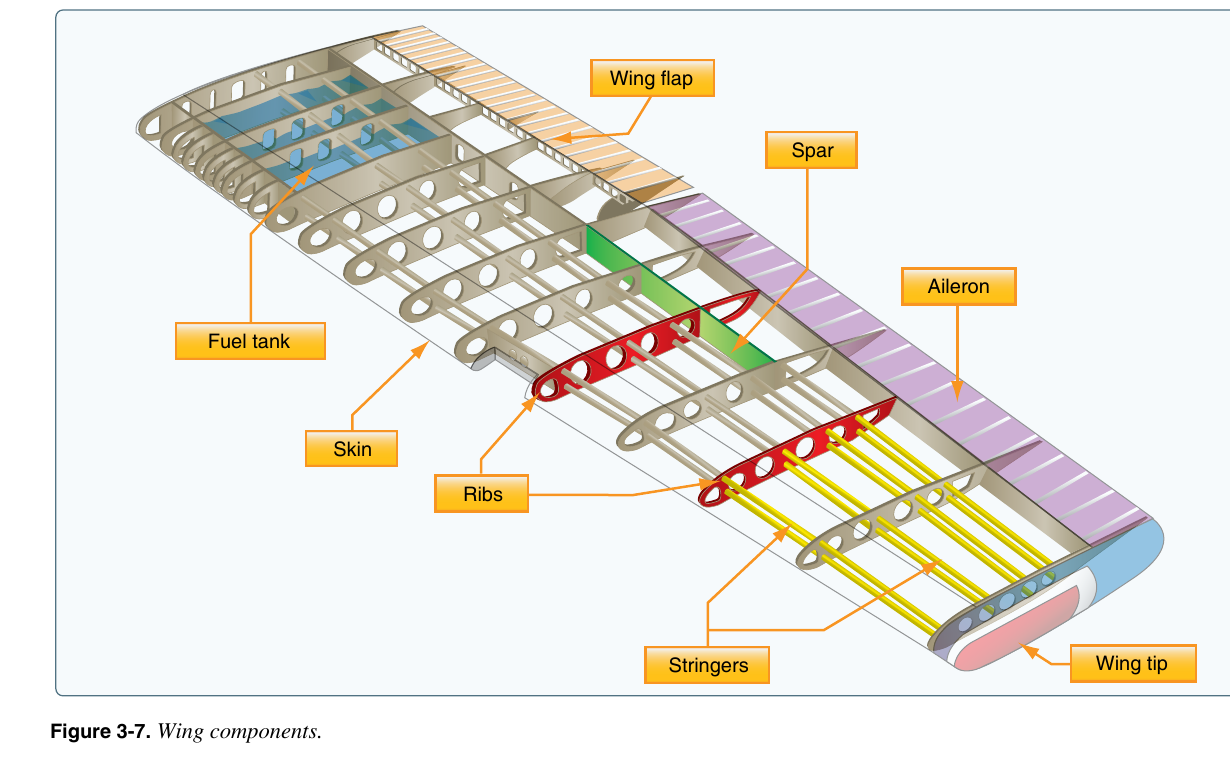

Read the component names as a **load-transfer system**, not as a vocabulary list:

- **Skin:** the thin outer shell that receives distributed aerodynamic traction. In a stressed-skin wing it carries in-plane shear flow, helps resist torsion, and transfers load into ribs, stringers, and spars.
- **Stringers:** slender spanwise stiffeners attached to the skin; the dedicated explanation below distinguishes their role from ribs and spars.
- **Ribs:** chordwise frames that preserve the airfoil shape, collect local skin loads, transfer them to the spars, and shorten unsupported skin panels.
- **Spars:** primary spanwise beams. Spar caps carry much of the bending-induced normal force; spar webs carry much of the transverse shear.
- **Wing box:** the closed structural cell formed mainly by the front and rear spars plus the upper and lower skins. Its closed section makes it efficient in both bending and torsion.
- **Wing root:** the attachment region where the wing joins the fuselage. Loads accumulated along the span pass through this interface, so root shear, bending moment, and torsion are commonly largest here.
- **Fuselage:** the aircraft body that receives the wing-root resultants and transfers them through frames, bulkheads, longerons, and the rest of the airframe.

Now cut the right wing at span station $y$, with $y=0$ at the root and $y=b/2$ at the tip. For the illustrated upward distributed load $q_z(\eta)$, the **magnitudes** required to equilibrate the outboard portion are
$$
\boxed{V_z(y)=\int_y^{b/2}q_z(\eta)\,d\eta}
\qquad\text{(internal shear force)},
$$
$$
\boxed{M_x(y)=\int_y^{b/2}(\eta-y)q_z(\eta)\,d\eta}
\qquad\text{(bending moment about the chordwise axis)},
$$
$$
\boxed{T_y(y)=\int_y^{b/2}\left[e(\eta)q_z(\eta)+m_y(\eta)\right]d\eta}
\qquad\text{(torsion about the spanwise axis)}.
$$
Here $e$ is the chordwise offset between the applied load line and the shear center, and $m_y$ is any distributed aerodynamic pitching moment. **Shear** tends to slide adjacent cross-sections, **bending** curves the wing, and **torsion** twists each section. Signs depend on the chosen axis convention; the equations above report magnitudes for the loading shown in the next figure.

**Source for the cutaway:** Federal Aviation Administration, *Pilot's Handbook of Aeronautical Knowledge*, Chapter 3, Figure 3-7, page 3-5.  
https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf

#### What exactly is a stringer?

In Figure 3-7 the yellow members run **along the span**, while the ribs cross the wing approximately chordwise. A stringer is a relatively small longitudinal stiffener, often with an angle, hat or Z-shaped section, joined to the skin. It supports a strip of skin between ribs, helps prevent that thin skin from buckling under compression, and can share spanwise axial load caused by wing bending. It is not a synonym for a rib or a spar.

For an attached skin–stringer pair that deforms compatibly, the axial strain is approximately shared locally. In a simple elastic axial model, $N_s=E_sA_s\varepsilon$ for the stringer and $N_{\mathrm{skin}}=E_{\mathrm{skin}}A_{\mathrm{effective}}\varepsilon$ for the participating skin. Thus stiffness $EA$ helps determine load sharing; merely counting the number of stringers does not. Effective skin width and buckling require further analysis.

| Part | Typical orientation | Main teaching distinction |
|---|---|---|
| Stringer | Spanwise along the skin | Small longitudinal stiffener; supports skin and shares normal load |
| Rib | Chordwise | Preserves airfoil contour and transfers local loads |
| Spar | Spanwise, with caps and web | Major beam transferring bending and shear |
| Skin | Covers the wing | Receives aerodynamic pressure; can carry structural normal stress and shear |

With the wing bending upward under a typical positive-lift ground-reference picture, the upper region is commonly in compression and the lower region in tension; reversed loading reverses the roles. Stringers on the compression side are especially important for panel stability. Internal wing loads must ultimately include the relevant aerodynamic, fuel-weight, structural-weight and inertia loads; the preceding integrals illustrate only the specified net line load.

The figure also identifies **flaps** (usually deflected together to change lift/drag), **ailerons** (usually differential to command roll), and a **fuel tank**. These are not interchangeable structural members: hinges and tank supports introduce loads that the surrounding structure must carry. Fuel also contributes to total aircraft mass and CG.

**Check understanding:** point to a rib, a spar and a stringer; describe the direction each runs. Then explain why removing a stringer can reduce compression capacity even when the airfoil's outer shape is unchanged.


In [ ]:
#@title 7B. Figure — wing components, load path, shear, bending, and torsion { display-mode: "form" }
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17.0, 6.4), gridspec_kw={"wspace": 0.27})

# ---------- Panel A: structural anatomy in plan view ----------
ax1.set_xlim(-0.8, 10.2)
ax1.set_ylim(-0.35, 7.2)
ax1.axis("off")

# Fuselage and tapered wing skin
ax1.add_patch(Rectangle((-0.55, 0.65), 1.35, 5.95, facecolor="#C9CED3", edgecolor="#303840", lw=1.8))
leading = lambda s: 6.05 - 1.20*(s-0.70)/8.90
trailing = lambda s: 1.05 + 1.15*(s-0.70)/8.90
wing = np.array([[0.70, trailing(0.70)], [0.70, leading(0.70)],
                 [9.60, leading(9.60)], [9.60, trailing(9.60)]])
ax1.add_patch(Polygon(wing, closed=True, facecolor="#DCECF7", edgecolor=COLORS["navy"], lw=2.2, alpha=0.72))

# Spar locations and translucent wing-box cell
stations = np.linspace(0.70, 9.60, 100)
front_y = np.array([leading(s) - 0.30*(leading(s)-trailing(s)) for s in stations])
rear_y = np.array([leading(s) - 0.70*(leading(s)-trailing(s)) for s in stations])
box_poly = np.column_stack([np.r_[stations, stations[::-1]], np.r_[front_y, rear_y[::-1]]])
ax1.add_patch(Polygon(box_poly, closed=True, facecolor="#FFE699", edgecolor="none", alpha=0.62, zorder=2))
ax1.plot(stations, front_y, color=COLORS["blue"], lw=5, solid_capstyle="round", zorder=4)
ax1.plot(stations, rear_y, color=COLORS["orange"], lw=5, solid_capstyle="round", zorder=4)

# Ribs, drawn above the translucent skin
for s in np.linspace(1.25, 9.05, 7):
    ax1.plot([s, s], [trailing(s)+0.08, leading(s)-0.08], color="#606A73", lw=2.0, zorder=3)

# Root attachment
ax1.plot([0.72, 0.72], [trailing(0.72), leading(0.72)], color=COLORS["red"], lw=6, zorder=5)

label_box = dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#B0B7BE", alpha=0.96)
ax1.annotate("fuselage", xy=(0.05, 5.45), xytext=(-0.55, 6.80),
             arrowprops=dict(arrowstyle="->", color="#303840"), color="#303840", weight="bold", bbox=label_box)
ax1.annotate("wing root\nattachment", xy=(0.72, 3.40), xytext=(1.25, 6.72),
             arrowprops=dict(arrowstyle="->", color=COLORS["red"]), color=COLORS["red"], weight="bold", bbox=label_box)
ax1.annotate("skin\n(transparent here)", xy=(8.50, 4.65), xytext=(8.05, 6.52),
             arrowprops=dict(arrowstyle="->", color=COLORS["navy"]), color=COLORS["navy"], weight="bold", bbox=label_box)
ax1.annotate("front spar", xy=(5.2, np.interp(5.2, stations, front_y)), xytext=(4.25, 6.22),
             arrowprops=dict(arrowstyle="->", color=COLORS["blue"]), color=COLORS["blue"], weight="bold", bbox=label_box)
ax1.annotate("rear spar", xy=(5.6, np.interp(5.6, stations, rear_y)), xytext=(6.10, 0.52),
             arrowprops=dict(arrowstyle="->", color=COLORS["orange"]), color=COLORS["orange"], weight="bold", bbox=label_box)
ax1.annotate("rib", xy=(7.75, 3.65), xytext=(8.72, 5.68),
             arrowprops=dict(arrowstyle="->", color="#606A73"), color="#505860", weight="bold", bbox=label_box)
ax1.annotate("closed wing box", xy=(3.55, 3.55), xytext=(2.15, 0.58),
             arrowprops=dict(arrowstyle="->", color="#9A6A00"), color="#7A5400", weight="bold", bbox=label_box)
ax1.text(5.0, 3.43, "upper/lower skin + spar webs", ha="center", va="center", fontsize=9,
         color="#7A5400", weight="bold", zorder=6)
ax1.set_title("A. WING ANATOMY AND LOAD-TRANSFER COMPONENTS", color=COLORS["navy"], fontsize=12.5, pad=14)

# Load-path strip
ax1.text(5.0, -0.30, "skin  →  ribs/stringers  →  spars & wing box  →  wing root  →  fuselage",
         ha="center", va="bottom", color=COLORS["navy"], weight="bold", fontsize=10.5)

# ---------- Panel B: internal resultants at a cut ----------
ax2.set_xlim(0.0, 10.0)
ax2.set_ylim(0.0, 7.2)
ax2.axis("off")

# Side-view cantilever and root support
ax2.add_patch(Rectangle((0.45, 2.45), 0.85, 2.35, facecolor="#C9CED3", edgecolor="#303840", lw=1.8))
beam = np.array([[1.30, 3.00], [1.30, 4.05], [9.50, 3.72], [9.50, 3.30]])
ax2.add_patch(Polygon(beam, closed=True, facecolor="#DCECF7", edgecolor=COLORS["navy"], lw=2.2))

# Distributed upward aerodynamic load q_z
for s, length in zip(np.linspace(1.75, 9.1, 9), np.linspace(1.25, 0.62, 9)):
    top = 4.03 - 0.33*(s-1.30)/8.20
    ax2.add_patch(FancyArrowPatch((s, top+0.05), (s, top+length), arrowstyle="-|>",
                                  mutation_scale=12, lw=1.7, color=COLORS["cyan"]))
ax2.text(5.5, 5.55, r"distributed aerodynamic load $q_z(y)$", ha="center",
         color=COLORS["blue"], weight="bold")

# Dashed cut plane
cut_x = 5.25
ax2.plot([cut_x, cut_x], [1.18, 5.60], ls="--", lw=2.0, color="#505050")
ax2.text(cut_x, 5.82, "imaginary cut at span station y", ha="center", color="#404040", weight="bold")
ax2.text(8.05, 2.86, "outboard free body", ha="center", color=COLORS["gray"], style="italic")

# Shear force at the cut: opposite the net upward load on the outboard free body
ax2.add_patch(FancyArrowPatch((5.62, 4.58), (5.62, 2.15), arrowstyle="-|>",
                              mutation_scale=18, lw=3.2, color=COLORS["red"]))
ax2.annotate(r"internal shear $V_z$"+"\n(resists sliding)", xy=(5.62, 2.30), xytext=(5.45, 0.92),
             arrowprops=dict(arrowstyle="->", color=COLORS["red"]), color=COLORS["red"],
             weight="bold", bbox=label_box)

# Bending moment: curved arrow in the side-view plane
ax2.add_patch(Arc((5.15, 3.50), 2.25, 2.85, theta1=55, theta2=300, lw=3.0, color=COLORS["orange"]))
ax2.add_patch(FancyArrowPatch((4.20, 2.72), (4.00, 3.02), arrowstyle="-|>",
                              mutation_scale=17, lw=2.7, color=COLORS["orange"]))
ax2.annotate(r"bending moment $M_x$"+"\n(curves the wing)", xy=(4.12, 2.87), xytext=(1.65, 0.45),
             arrowprops=dict(arrowstyle="->", color=COLORS["orange"]), color=COLORS["orange"],
             weight="bold", bbox=label_box)

# Torsion: elliptical rotation about the spanwise beam axis
ax2.add_patch(Arc((7.55, 3.52), 1.12, 2.12, theta1=35, theta2=330, lw=3.0, color="#7030A0"))
ax2.add_patch(FancyArrowPatch((7.03, 3.08), (7.02, 3.42), arrowstyle="-|>",
                              mutation_scale=16, lw=2.7, color="#7030A0"))
ax2.annotate(r"torsion $T_y$"+"\n(twists the section)", xy=(7.05, 3.42), xytext=(7.45, 0.15),
             arrowprops=dict(arrowstyle="->", color="#7030A0"), color="#7030A0",
             weight="bold", bbox=label_box)

# Axes and span label
ax2.add_patch(FancyArrowPatch((1.45, 2.15), (3.05, 2.15), arrowstyle="-|>", mutation_scale=13, lw=1.6, color="#303840"))
ax2.text(2.25, 1.88, "spanwise y", ha="center", color="#303840")
ax2.add_patch(FancyArrowPatch((1.45, 2.15), (1.45, 3.05), arrowstyle="-|>", mutation_scale=13, lw=1.6, color="#303840"))
ax2.text(1.16, 2.60, "z", ha="center", color="#303840")
ax2.text(0.87, 5.00, "fuselage /\nroot restraint", ha="center", color="#303840", weight="bold")
ax2.set_title("B. INTERNAL RESULTANTS AT A SPANWISE CUT", color=COLORS["navy"], fontsize=12.5, pad=14)

fig.suptitle("From aerodynamic surface load to structural resultants", fontsize=16,
             color=COLORS["navy"], weight="bold", y=1.02)
plt.show()


### 7D. Truss fuselage: triangulation and axial member forces — Figure 3-5

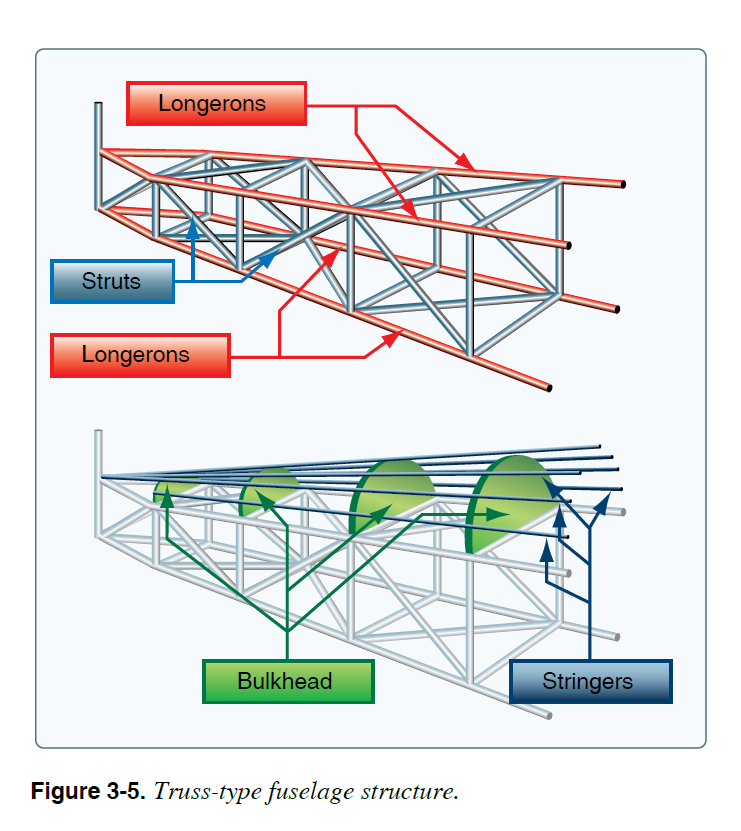

*FAA Figure 3-5, printed page 3-4. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=4). The explanation and calculations below are course additions.*

In the upper drawing, **longerons** are the main lengthwise members and the connecting struts/braces form triangulated bays. An unbraced four-sided frame can distort by changing its corner angles; triangles constrain that change of shape. The three-dimensional assembly transfers loads between the wing, tail, engine and fuselage attachments.

For an ideal pin-jointed truss, straight members carry axial tension or compression, joint loads act at the nodes, and each joint satisfies

$$\boxed{\sum_j N_j\hat{\mathbf e}_j+\mathbf P_{\mathrm{joint}}=\mathbf0.}$$

$N_j$ is the signed member force, $\hat{\mathbf e}_j$ points away from the joint along that member, and $\mathbf P_{\mathrm{joint}}$ is the externally applied joint load. Taking $N_j>0$ means tension. In a planar joint, resolve this equation into $\sum F_x=0$ and $\sum F_z=0$; in a space truss use three components. Do not assume every member labeled “strut” is always in compression: the load case determines the sign.

Once a member force is known, an axial elastic estimate is

$$\sigma=\frac{N}{A},\qquad\delta=\frac{N\ell}{EA}.$$

$A$ is member area, $\ell$ its length and $E$ Young's modulus. $N/A$ checks axial stress; it does not check compression buckling. A slender compressed member can buckle before reaching its material compressive strength. Real welded joints and loads applied between nodes can also introduce member bending, outside the pure axial idealization.

The lower drawing adds formers/bulkheads and slender **stringers** around the truss to shape and support its covering. In a fabric-covered truss aircraft, that covering is not generally treated as the principal global bending/torsion structure. This differs from a stressed-skin semimonocoque, where skin and stiffeners participate directly in the main load path. The name “stringer” alone does not tell you how much load it carries; its attachment and structural arrangement matter.


### 7E. Monocoque versus semimonocoque — Figure 3-14

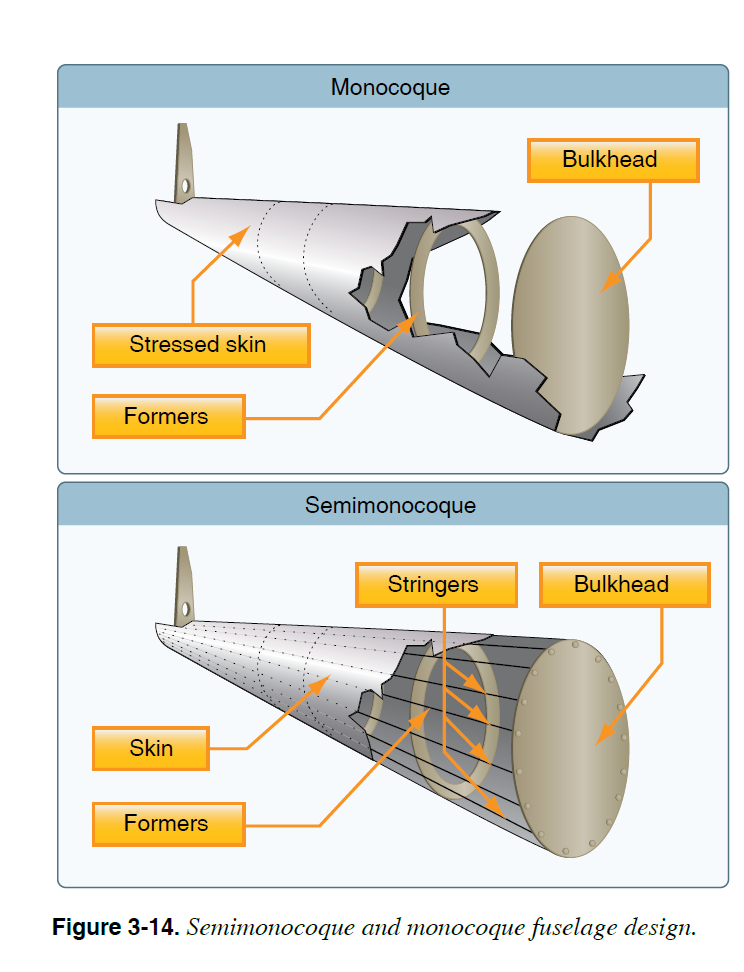

*FAA Figure 3-14, printed page 3-9. [Source: Pilot's Handbook of Aeronautical Knowledge, Chapter 3](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf#page=9). The explanation and calculations below are course additions.*

The two drawings answer a load-path question: **which parts carry the fuselage loads?** “Stressed skin” means the outer shell is structural, not merely a fairing.

| Construction | Main load-carrying concept | Role of internal members |
|---|---|---|
| Truss with nonstructural covering | Braced framework carries the main global loads | Outer shaping members support the covering |
| Monocoque | Shell carries most of the main loads | Formers/bulkheads maintain shape and introduce or distribute concentrated loads |
| Semimonocoque | Skin and longitudinal stiffeners share loads | Stringers/longerons reinforce the shell; transverse frames and bulkheads stabilize shape and distribute attachment loads |

A **former or frame** generally runs around the cross-section and supports its shape. A **bulkhead** is a transverse structural partition or substantial load-distribution member; it can receive concentrated attachment loads and, when designed for it, pressure loads. These names overlap in practice, so inspect the actual design rather than assigning identical duties to every ring.

Under fuselage bending, material on one side is in longitudinal tension and the other in compression. Skin and longitudinal stiffeners share those normal loads according to stiffness and placement. The skin also carries in-plane shear. For an ideal single-cell thin-walled closed shell under torque,

$$q_s=\frac{T}{2A_m},\qquad\tau=\frac{q_s}{t}.$$

Here $T$ is torque (N m), $A_m$ the area enclosed by the wall median line (m$^2$), $q_s$ shear flow (N/m), and $t$ wall thickness (m). We use $q_s$ to distinguish shear flow from aerodynamic dynamic pressure $q$. The result assumes a closed single cell; cutouts, joints and multicell structures require additional analysis. It explains why an attached shell can carry torsion efficiently.

Stringers subdivide and stiffen compression-loaded skin; frames support its transverse shape. They do not make buckling impossible, and a dent or damaged joint can disrupt the load path. **Semimonocoque does not mean exactly half the load is in the skin.** Load sharing depends on the structure.

**Connect to wing design:** the wing's skin–stringer–rib–spar system and the fuselage's skin–stringer–frame system use the same idea: place material efficiently, stabilize thin panels, and connect the load path. An airfoil outline alone supplies none of the wall thicknesses, joints or strength checks needed to establish load capacity.


In [ ]:
#@title 7C. AI audit — check answer ▶ decide what the evidence can support { display-mode: "form" }
#@markdown **Question:** What can the geometry plot and a successful print actually establish about structural strength?
#@markdown Choose the defensible evidence statement, request one independent check, then press **▶** to check.
EVIDENCE_LEVEL = "Choose"  #@param ["Choose", "NACA plot proves the wing is strong", "A successful print proves the flight load is safe", "Geometry and print are evidence, but strength still needs a structural check"]
AI_AUDIT_NOTE = ""  #@param {type:"string"}

if EVIDENCE_LEVEL == "Choose" or not AI_AUDIT_NOTE.strip():
    display(Markdown("⚠️ Choose the defensible statement and write the check you would request from an AI-generated answer."))
elif EVIDENCE_LEVEL == "Geometry and print are evidence, but strength still needs a structural check":
    display(Markdown(
        f"✅ **Defensible evidence boundary.** Geometry and fabrication are necessary evidence, not proof of strength.  \n"
        f"**Your requested check:** {AI_AUDIT_NOTE}"
    ))
else:
    display(Markdown(
        "❌ A geometry plot or successful print does not establish stress, buckling resistance, joint integrity, or load capacity."
    ))

---
## 8. Exit ticket

Write a compact engineering statement using the five course labels. A good response can be only five sentences, but each sentence must do a different job.

In [ ]:
#@title 8A. Submit your Claim–Evidence–Check–Confidence–Limitation record { display-mode: "form" }
#@markdown **Exit record:** Write a Claim–Evidence–Check–Confidence–Limitation statement about one result from this lecture.
#@markdown Complete all five boxes, then press **▶** to check completeness.
EXIT_CLAIM = ""  #@param {type:"string"}
EXIT_EVIDENCE = ""  #@param {type:"string"}
EXIT_CHECK = ""  #@param {type:"string"}
EXIT_CONFIDENCE = ""  #@param {type:"string"}
EXIT_LIMITATION = ""  #@param {type:"string"}

fields = [EXIT_CLAIM, EXIT_EVIDENCE, EXIT_CHECK, EXIT_CONFIDENCE, EXIT_LIMITATION]
names = ["Claim", "Evidence", "Check", "Confidence", "Limitation"]
missing = [name for name, value in zip(names, fields) if not value.strip()]

if missing:
    display(Markdown("⚠️ Complete: **" + ", ".join(missing) + "**."))
else:
    display(Markdown(
        f"### Your engineering record\n"
        f"- **Claim:** {EXIT_CLAIM}\n"
        f"- **Evidence:** {EXIT_EVIDENCE}\n"
        f"- **Check:** {EXIT_CHECK}\n"
        f"- **Confidence:** {EXIT_CONFIDENCE}\n"
        f"- **Limitation:** {EXIT_LIMITATION}"
    ))

## After class: optional extensions

Use these as investigation prompts between sessions or for additional in-class discussion:

1. In the force-balance cell, first set $\gamma=0$, $L=W$, and $T=D$; confirm both acceleration components become zero. Then set $\gamma=10^\circ$ and test the steady-path relations $L=W\cos\gamma$ and $T-D=W\sin\gamma$.
2. Compare NACA 0012, 2412, and 4412. Isolate thickness from camber by changing one feature at a time.
3. In the coefficient cell, double speed. Predict the lift ratio before running.
4. In the angle-of-attack cell, move the test point beyond the assumed stall angle. Explain why the dashed linear model becomes unsafe to extrapolate.
5. Ask an AI system to explain why an airfoil generates lift. Audit the response for the equal-transit-time myth, missing assumptions, and absent validation evidence.

### Five ideas to retain

- Equilibrium is a condition to check, not an automatic property of flight.
- Airfoil shape and angle of attack are different.
- Surface pressure is normal locally; shear is tangent locally.
- Coefficient equations are conditional models, and speed enters through $V^2$.
- A geometry plot or successful print is not proof of structural strength.

### FAA figure review and source boundary

Revisit Figures 3-2 and 3-3: identify each rotation axis, write the vector moment equation, and explain why weight produces no moment about the CG. Use the trim cell to check one CG shift and distinguish equilibrium from stability. Revisit Figures 3-10 and 3-11: distinguish an aircraft pitching moment from a control hinge moment. Finally, compare Figures 3-5, 3-7 and 3-14 by tracing the load through their named members.

**Source:** Federal Aviation Administration, [*Pilot's Handbook of Aeronautical Knowledge*, Chapter 3: Aircraft Construction](https://www.faa.gov/sites/faa.gov/files/05_phak_ch3_0.pdf), Figures 3-2 (p. 3-3), 3-3 and 3-5 (p. 3-4), 3-7 (p. 3-5), 3-10 (p. 3-6), 3-11 (p. 3-7), and 3-14 (p. 3-9). Figure images are embedded in this notebook, so they do not depend on temporary local files. The equations, numerical trim example and comparison tables are teaching additions; they are not performance data or operating limits for the depicted aircraft.
